# Library and Data Imports and Standardization

In [1]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Import the classification report
from sklearn.metrics import classification_report

# Import the f1 score
from sklearn.metrics import f1_score

# Import train test split
from sklearn.model_selection import train_test_split

# Import KFold
from sklearn.model_selection import KFold

# Import pickle
import pickle

# Import t-SNE and UMAP
from sklearn.manifold import TSNE
import umap

# Import random
import random
random.seed(42)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import the datasets

In [2]:
pickle_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/pickle/'

In [3]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_X_train_combined_resampled.pkl', 'rb') as f:
    convabuse_combined_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_X_test_combined_resampled.pkl', 'rb') as f:
    convabuse_combined_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_y_train_combined_resampled.pkl', 'rb') as f:
    convabuse_combined_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_y_test_combined_resampled.pkl', 'rb') as f:
    convabuse_combined_y_test = pickle.load(f)

In [4]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_prev_agent_X_train_resampled.pkl', 'rb') as f:
    convabuse_prev_agent_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_X_test_resampled.pkl', 'rb') as f:
    convabuse_prev_agent_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_y_train_resampled.pkl', 'rb') as f:
    convabuse_prev_agent_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_y_test_resampled.pkl', 'rb') as f:
    convabuse_prev_agent_y_test = pickle.load(f)

In [5]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_prev_user_X_train_resampled.pkl', 'rb') as f:
    convabuse_prev_user_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_X_test_resampled.pkl', 'rb') as f:
    convabuse_prev_user_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_y_train_resampled.pkl', 'rb') as f:
    convabuse_prev_user_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_y_test_resampled.pkl', 'rb') as f:
    convabuse_prev_user_y_test = pickle.load(f)

In [6]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_agent_X_train_resampled.pkl', 'rb') as e:
    convabuse_agent_X_train = pickle.load(e)
with open(f'{pickle_path}convabuse_agent_X_test_resampled.pkl', 'rb') as f:
    convabuse_agent_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_agent_y_train_resampled.pkl', 'rb') as g:
    convabuse_agent_y_train = pickle.load(g)
with open(f'{pickle_path}convabuse_agent_y_test_resampled.pkl', 'rb') as h:
    convabuse_agent_y_test = pickle.load(h)

In [7]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_user_X_train_resampled.pkl', 'rb') as e:
    convabuse_user_X_train = pickle.load(e)
with open(f'{pickle_path}convabuse_user_X_test_resampled.pkl', 'rb') as f:
    convabuse_user_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_user_y_train_resampled.pkl', 'rb') as g:
    convabuse_user_y_train = pickle.load(g)
with open(f'{pickle_path}convabuse_user_y_test_resampled.pkl', 'rb') as h:
    convabuse_user_y_test = pickle.load(h)

In [8]:
# Open the pickled embeddings
with open(f'{pickle_path}dghs_target_X_train_resampled.pkl', 'rb') as e:
    dynamically_generated_hate_speech_target_X_train = pickle.load(e)
with open(f'{pickle_path}dghs_target_X_test_resampled.pkl', 'rb') as f:
    dynamically_generated_hate_speech_target_X_test = pickle.load(f)
with open(f'{pickle_path}dghs_target_y_train_resampled.pkl', 'rb') as g:
    dynamically_generated_hate_speech_target_y_train = pickle.load(g)
with open(f'{pickle_path}dghs_target_y_test_resampled.pkl', 'rb') as h:
    dynamically_generated_hate_speech_target_y_test = pickle.load(h)

In [9]:
# Open the pickled embeddings
with open(f'{pickle_path}dghs_label_X_train_resampled.pkl', 'rb') as e:
    dynamically_generated_hate_speech_label_X_train = pickle.load(e)
with open(f'{pickle_path}dghs_label_X_test_resampled.pkl', 'rb') as f:
    dynamically_generated_hate_speech_label_X_test = pickle.load(f)
with open(f'{pickle_path}dghs_label_y_train_resampled.pkl', 'rb') as g:
    dynamically_generated_hate_speech_label_y_train = pickle.load(g)
with open(f'{pickle_path}dghs_label_y_test_resampled.pkl', 'rb') as h:
    dynamically_generated_hate_speech_label_y_test = pickle.load(h)

In [10]:
# Open the pickled embeddings
with open(f'{pickle_path}mlma_hate_speech_target_X_train_resampled.pkl', 'rb') as e:
    mlma_hate_speech_target_X_train = pickle.load(e)
with open(f'{pickle_path}mlma_hate_speech_target_X_test_resampled.pkl', 'rb') as f:
    mlma_hate_speech_target_X_test = pickle.load(f)
with open(f'{pickle_path}mlma_hate_speech_target_y_train_resampled.pkl', 'rb') as g:
    mlma_hate_speech_target_y_train = pickle.load(g)
with open(f'{pickle_path}mlma_hate_speech_target_y_test_resampled.pkl', 'rb') as h:
    mlma_hate_speech_target_y_test = pickle.load(h)

In [11]:
regularizers = ["l1", "l2"]

In [12]:
solvers = ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]

In [13]:
l1_ratio_list = [0.5]

In [14]:
logistic_regression_model_results = []

In [15]:
logistic_regression_TSNE = {}

In [16]:
logistic_regression_UMAP = {}

## Convabuse Logistic Regression

In [21]:
def logistic_regression_modeling(X_train, X_test, y_train, y_test, target, dataset):
  results_list = []

  # Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Convabuse dataset
  for regularizer in regularizers:
    for solver in solvers:
      if regularizer == "l1" and solver not in ["liblinear", "saga"]:
        continue
      # Add condition for elasticnet and solver saga in the first loop
      if regularizer == "elasticnet" and solver != "saga":
          continue
      logistic_regression = LogisticRegression(penalty=regularizer, solver=solver, random_state=42)
      logistic_regression.fit(X_train, y_train)
      # Predict the target variable for the test set
      y_pred = logistic_regression.predict(X_test)

      # Calculate the accuracy of the model
      accuracy = accuracy_score(y_test, y_pred)
      f1 = f1_score(y_test, y_pred, average='weighted') # Weighted average due to multiclass
      results_list.append((dataset, regularizer, solver, accuracy, f1, 0))
      print(f"Regularizer: {regularizer}, Solver: {solver}, Accuracy: {accuracy}, F1-score: {f1}")

  for ratio in l1_ratio_list:
      logistic_regression = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=ratio, random_state=42)
      logistic_regression.fit(X_train, y_train)
      # Predict the target variable for the test set
      y_pred = logistic_regression.predict(X_test)

      # Calculate the accuracy of the model
      accuracy = accuracy_score(y_test, y_pred)
      f1 = f1_score(y_test, y_pred, average='weighted')
      results_list.append((dataset, "elasticnet", "saga", accuracy, f1, ratio))
      print(f"Regularizer: elasticnet, l1_ratio: {ratio}, Accuracy: {accuracy}, F1-score: {f1}")

  # Convert the results list into a dataframe
  results = pd.DataFrame(results_list, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio"])

  best_model_params = results.loc[results["Accuracy"].idxmax()]
  best_model_params

  # Use the best parameters to create a new best model
  if best_model_params["Regularizer"] == "elasticnet":
      best_model = LogisticRegression(penalty=best_model_params["Regularizer"], solver=best_model_params["Solver"], l1_ratio=best_model_params["Ratio"], random_state=42)
  else:
      best_model = LogisticRegression(penalty=best_model_params["Regularizer"], solver=best_model_params["Solver"], random_state=42)

  best_model.fit(X_train, y_train)

  # Predict the target variable for the test set
  y_pred = best_model.predict(X_test)

  # Calculate the accuracy of the model
  accuracy = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred, average='weighted')

  # Calculate and plot the confusion matrix
  from sklearn.metrics import confusion_matrix
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='hot')
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.show()

  # Get the coefficients for each feature
  feature_importances = np.sum(best_model.coef_, axis=0)

  # Sort the feature importances
  feature_columns_sorted = np.argsort(feature_importances)[::-1]
  feature_importances_sorted = feature_importances[feature_columns_sorted]
  top_10_features = feature_columns_sorted[:10][::-1]
  top_10_feature_importances = feature_importances_sorted[:10][::-1]

  # Create a list of column names (assuming they are indexed from 0 to n-1)
  # This handles both pandas DataFrames and NumPy arrays
  if isinstance(X_train, pd.DataFrame):
    column_names = X_train.columns
  else:
    column_names = [i for i in range(X_train.shape[1])] # Use integer indices

  # Convert to a dictionary
  feature_importances_data = {}
  for feature, importance in zip(column_names, feature_importances):
    feature_importances_data[feature] = importance
  feature_importances_sorted_dict = {}
  for feature, importance in zip(column_names, feature_importances_sorted):
    feature_importances_sorted_dict[feature] = importance

  # Plot the top 10 feature importances as a horizontal bar chart
  plt.figure(figsize=(10, 6))
  # Use the actual integer indices of the top 10 features as labels
  sns.barplot(x=top_10_feature_importances, y=top_10_features.astype(str), palette='hot') # Convert to string for y-axis labels
  plt.xlabel("Importance")
  plt.ylabel("Feature Index")
  plt.title(f"Top 10 Feature Importances - {dataset}")
  plt.show()

  # Create a dictionary using the top 10 features and top 10 feature importances
  top_10_feature_importances_data = {feature: importance for feature, importance in zip(top_10_features, top_10_feature_importances)}

  # Print the dictionary
  print("Top 10 Feature Importances")
  print(top_10_feature_importances_data)

  print("Linear Coefficients")
  print(feature_importances_data)

  logistic_regression_model_results.append((dataset, best_model_params, accuracy, f1, 0.0, feature_importances_data, top_10_feature_importances_data))

  print(f"Regularizer: {best_model_params['Regularizer']}, Solver: {best_model_params['Solver']}, Accuracy: {accuracy}, F1-score: {f1}")

  X_train_df = pd.DataFrame(X_train)
  y_train_series = pd.Series(y_train)
  X_test_df = pd.DataFrame(X_test)

  # Get the best correlated feature with the target variable
  best_correlated_feature = X_train_df.corrwith(y_train_series).abs().idxmax()
  print(f"Best correlated feature: {best_correlated_feature}")

  # Plot the predictions that were generated as a histogram using seaborn colored by correct vs incorrect predictions
  sns.histplot(y_pred, kde=True, label='Predicted')
  plt.xlabel('Prediction')
  plt.ylabel('Frequency')
  plt.title(f'Histogram of Predictions - {dataset}')
  plt.show()

  # Plot the actual values
  sns.histplot(y_test, kde=True, label='Actual')
  plt.xlabel('Actual Value')
  plt.ylabel('Frequency')
  plt.title(f'Histogram of Actual Values - {dataset}')
  plt.show()

  # Plot the predictions that were generated as a scatterplot plotted against the best correlated feature
  sns.scatterplot(x=X_test_df[best_correlated_feature], y=y_pred, hue=y_test, palette='hot')
  plt.show()

  # Use t-sne and color code by the target variable

  # Reduce dimensionality of test data using t-SNE
  tsne_test = TSNE(n_components=2, random_state=42)
  X_test_tsne = tsne_test.fit_transform(X_test)

  # Create a scatter plot
  plt.figure(figsize=(10, 8))
  scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test, cmap='hot', alpha=0.6)
  plt.title(f't-SNE Visualization of {dataset} User Dataset')
  plt.xlabel('t-SNE Component 1')
  plt.ylabel('t-SNE Component 2')
  plt.colorbar(scatter, label=f'{target}')
  plt.show()

  # Calculate if predictions are correct (within a tolerance)
  tolerance = 0.5  # Define a tolerance for what is considered "correct"
  correct_predictions = np.abs(y_pred - y_test) <= tolerance

  # Create a scatter plot, coloring by correctness
  plt.figure(figsize=(10, 8))
  scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=correct_predictions, cmap='hot', alpha=0.6)
  plt.title(f't-SNE Visualization of {dataset} Test Data: Correct vs Incorrect Predictions')
  plt.xlabel('t-SNE Component 1')
  plt.ylabel('t-SNE Component 2')
  cbar = plt.colorbar(scatter, ticks=[0, 1])
  cbar.ax.set_yticklabels(['Incorrect', 'Correct'])
  plt.show()

  # Use UMAP and color code by the target variable
  # Reduce dimensionality using UMAP
  reducer = umap.UMAP(random_state=42)
  X_test_umap = reducer.fit_transform(X_test)

  # Create a scatter plot
  plt.figure(figsize=(10, 8))
  scatter = plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1], c=y_test, cmap='hot', alpha=0.6)
  plt.title(f'UMAP Visualization of {dataset} User Dataset')
  plt.xlabel('UMAP Component 1')
  plt.ylabel('UMAP Component 2')
  plt.colorbar(scatter, label=f'{target}')
  plt.show()

  logistic_regression_TSNE[dataset] = X_test_tsne
  logistic_regression_UMAP[dataset] = X_test_umap

  return results

Regularizer: l1, Solver: liblinear, Accuracy: 0.6396342675412443, F1-score: 0.635717140427331
Regularizer: l1, Solver: saga, Accuracy: 0.6444046909163188, F1-score: 0.64139333857191
Regularizer: l2, Solver: lbfgs, Accuracy: 0.6285032796660703, F1-score: 0.6259378511605866
Regularizer: l2, Solver: liblinear, Accuracy: 0.6171735241502684, F1-score: 0.613443151376354
Regularizer: l2, Solver: newton-cg, Accuracy: 0.6292983502285828, F1-score: 0.6263324100419814
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.6300934207910952, F1-score: 0.627621235200819
Regularizer: l2, Solver: sag, Accuracy: 0.6294971178692109, F1-score: 0.6269133131632058
Regularizer: l2, Solver: saga, Accuracy: 0.6300934207910952, F1-score: 0.627621235200819
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.6366527529318227, F1-score: 0.6338190612260121


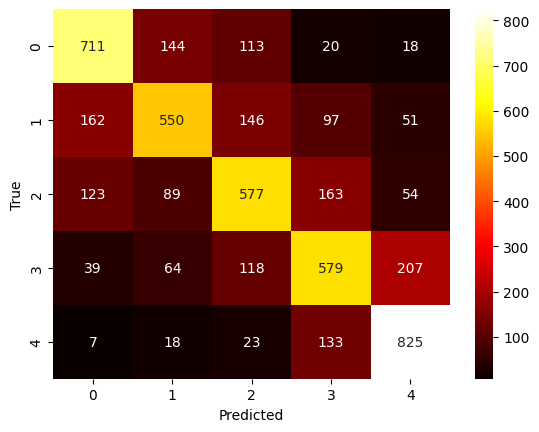

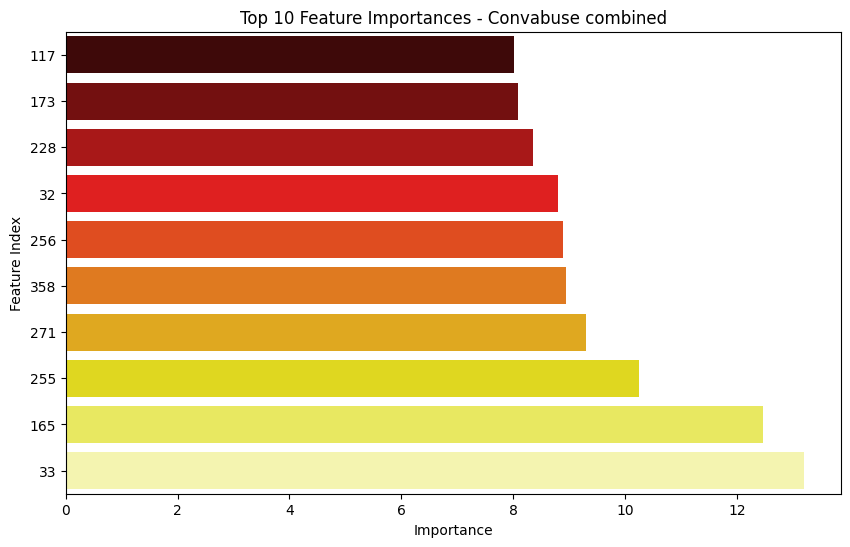

Top 10 Feature Importances
{np.int64(117): np.float32(8.011974), np.int64(173): np.float32(8.084111), np.int64(228): np.float32(8.3534), np.int64(32): np.float32(8.798795), np.int64(256): np.float32(8.900953), np.int64(358): np.float32(8.9485445), np.int64(271): np.float32(9.297289), np.int64(255): np.float32(10.24313), np.int64(165): np.float32(12.472785), np.int64(33): np.float32(13.200304)}
Linear Coefficients
{0: np.float32(-0.20279072), 1: np.float32(-0.69691426), 2: np.float32(6.02564), 3: np.float32(0.7752415), 4: np.float32(-0.9190419), 5: np.float32(0.57442963), 6: np.float32(1.5100592), 7: np.float32(-0.069024324), 8: np.float32(-1.9242252), 9: np.float32(5.5978947), 10: np.float32(0.13597672), 11: np.float32(0.6698828), 12: np.float32(3.492198), 13: np.float32(-0.7387676), 14: np.float32(-2.7353425), 15: np.float32(0.8316541), 16: np.float32(0.7364459), 17: np.float32(-1.0603037), 18: np.float32(0.4671576), 19: np.float32(-1.5296818), 20: np.float32(-0.05422175), 21: np.floa

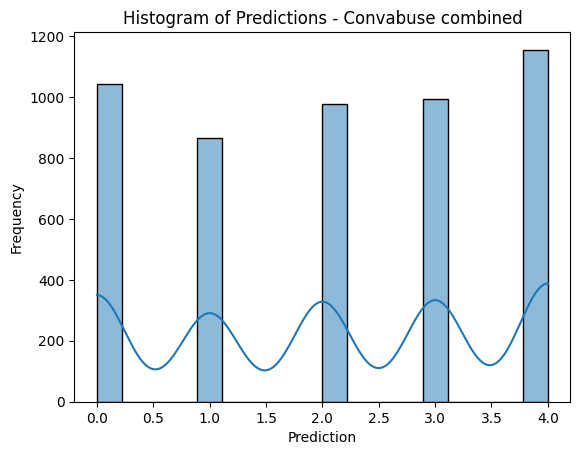

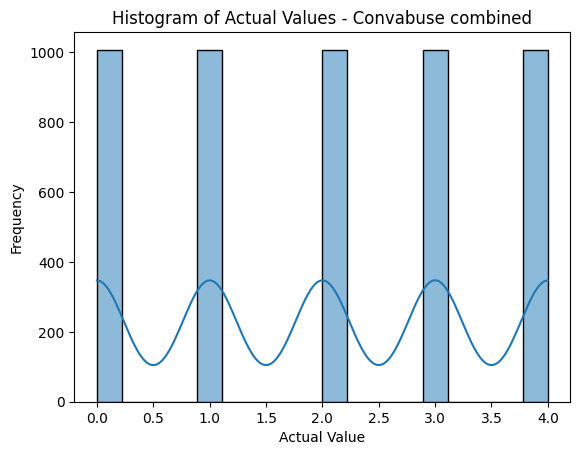

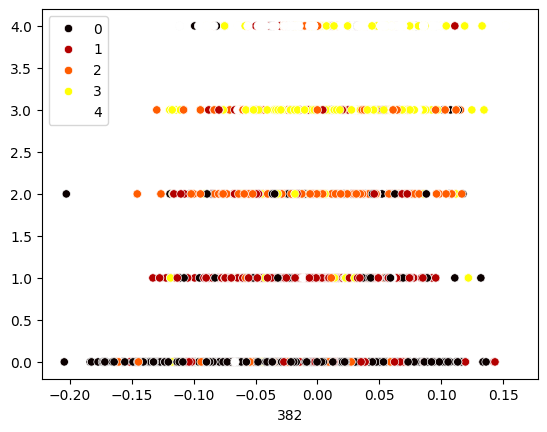

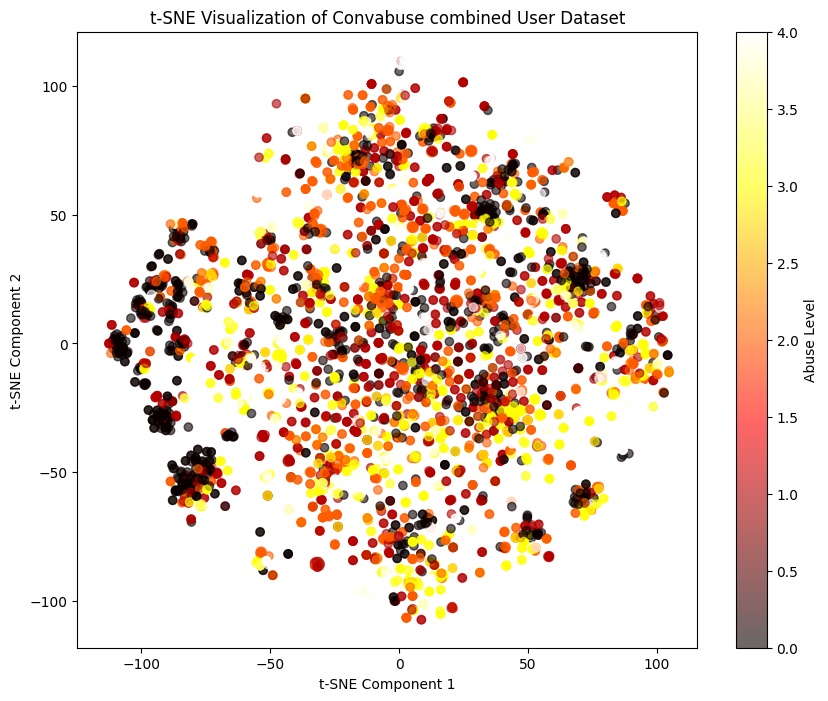

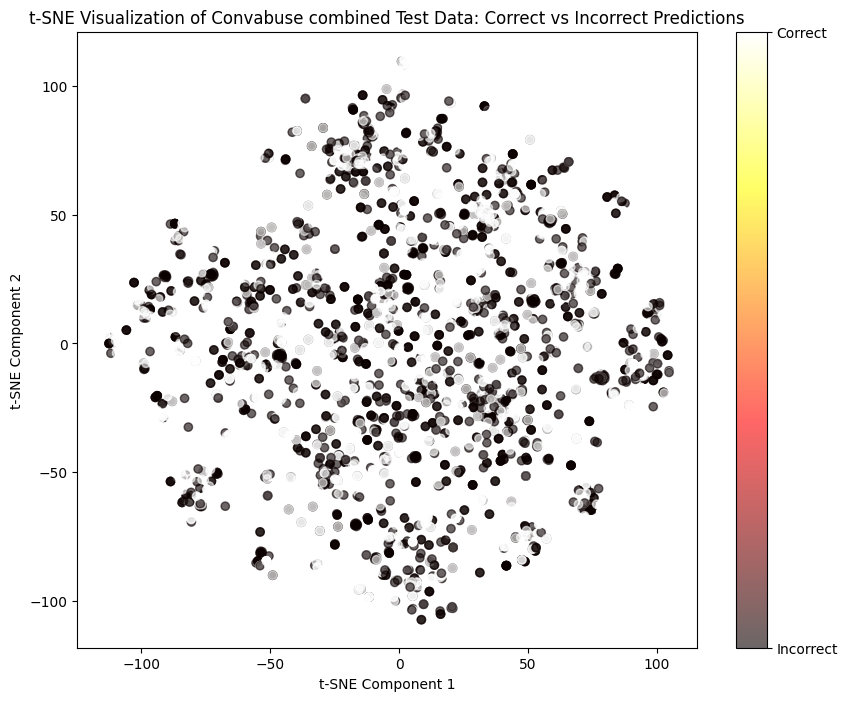

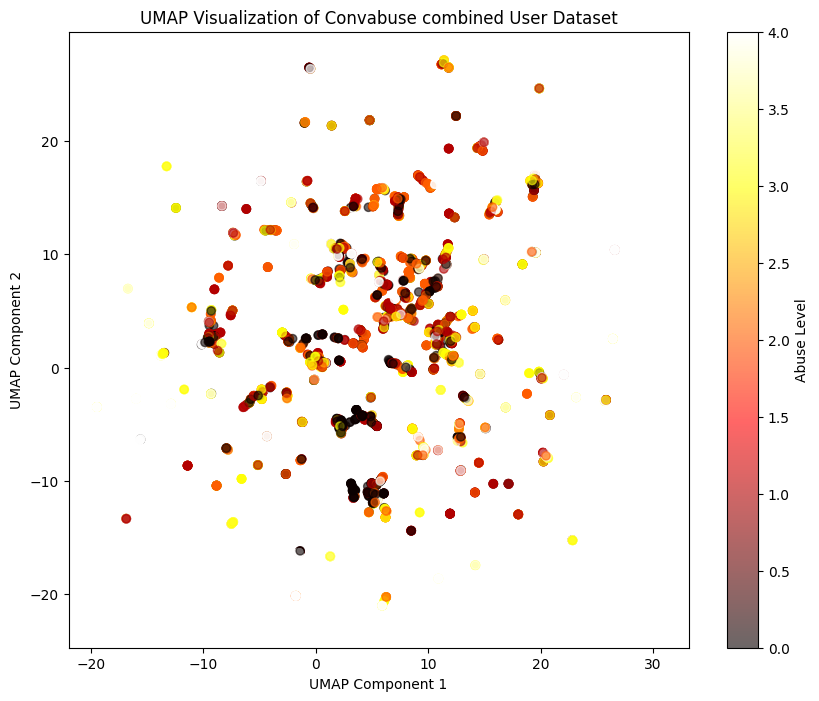

In [22]:
convabuse_combined_results_list = logistic_regression_modeling(convabuse_combined_X_train, convabuse_combined_X_test, convabuse_combined_y_train, convabuse_combined_y_test, "Abuse Level", "Convabuse combined")

Regularizer: l1, Solver: liblinear, Accuracy: 0.38302524349035977, F1-score: 0.3889433217731227
Regularizer: l1, Solver: saga, Accuracy: 0.38342277877161596, F1-score: 0.3886285576113723
Regularizer: l2, Solver: lbfgs, Accuracy: 0.38342277877161596, F1-score: 0.38847844068122667
Regularizer: l2, Solver: liblinear, Accuracy: 0.3814351023653349, F1-score: 0.38686899995708623
Regularizer: l2, Solver: newton-cg, Accuracy: 0.38461538461538464, F1-score: 0.3900450646271952
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.3850129198966408, F1-score: 0.39057363099030634
Regularizer: l2, Solver: sag, Accuracy: 0.3850129198966408, F1-score: 0.39057363099030634
Regularizer: l2, Solver: saga, Accuracy: 0.3850129198966408, F1-score: 0.39057363099030634
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.3838203140528722, F1-score: 0.38924571919207585


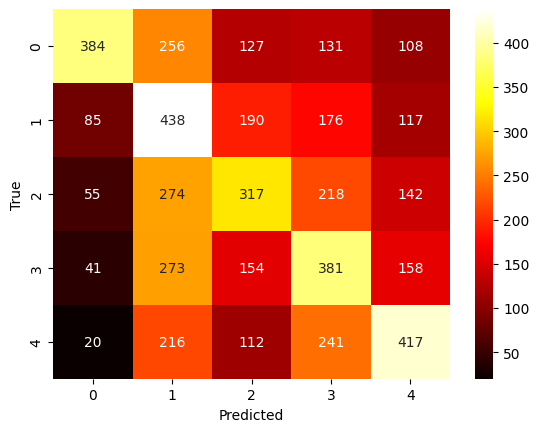

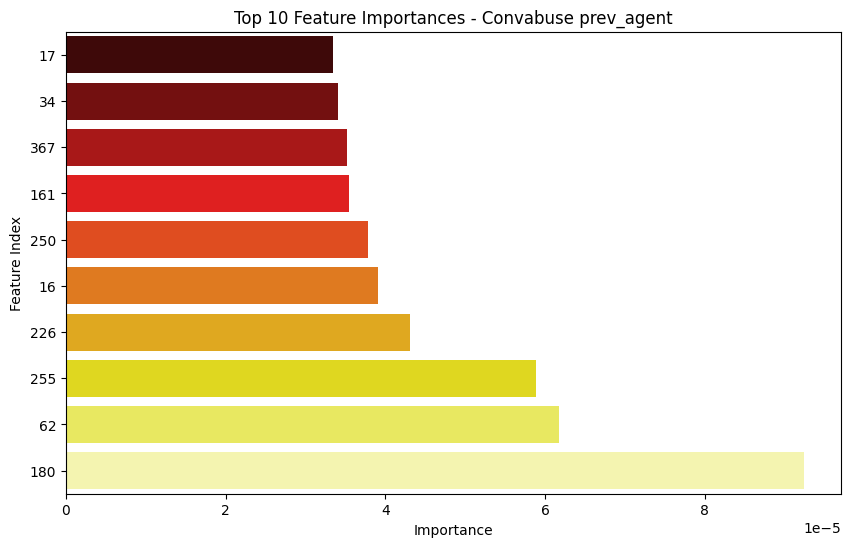

Top 10 Feature Importances
{np.int64(17): np.float32(3.349781e-05), np.int64(34): np.float32(3.4093857e-05), np.int64(367): np.float32(3.5226345e-05), np.int64(161): np.float32(3.5509467e-05), np.int64(250): np.float32(3.784895e-05), np.int64(16): np.float32(3.9100647e-05), np.int64(226): np.float32(4.3153763e-05), np.int64(255): np.float32(5.8829784e-05), np.int64(62): np.float32(6.175041e-05), np.int64(180): np.float32(9.2446804e-05)}
Linear Coefficients
{0: np.float32(-4.7683716e-07), 1: np.float32(1.3113022e-06), 2: np.float32(-2.734363e-06), 3: np.float32(1.6570091e-05), 4: np.float32(-4.0233135e-06), 5: np.float32(-1.8119812e-05), 6: np.float32(-4.220009e-05), 7: np.float32(-9.387732e-06), 8: np.float32(1.9431114e-05), 9: np.float32(-6.735325e-06), 10: np.float32(-5.00679e-06), 11: np.float32(2.8133392e-05), 12: np.float32(-1.168251e-05), 13: np.float32(1.4305115e-06), 14: np.float32(-6.4224005e-06), 15: np.float32(-2.9802322e-06), 16: np.float32(3.9100647e-05), 17: np.float32(3.

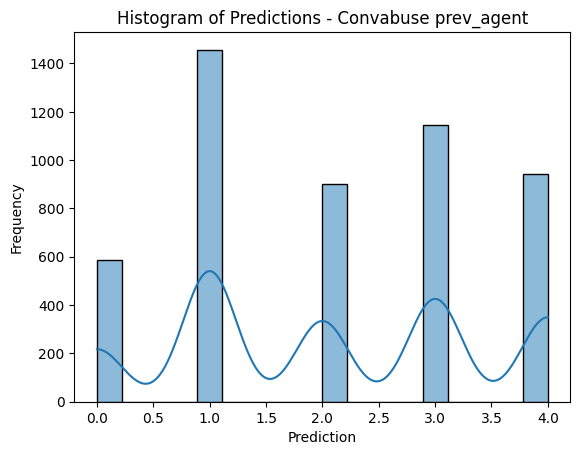

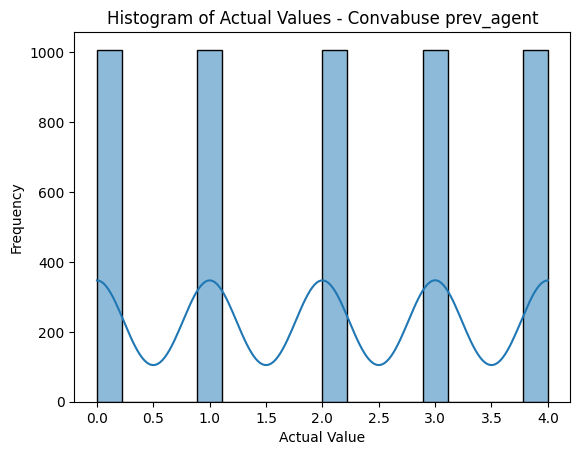

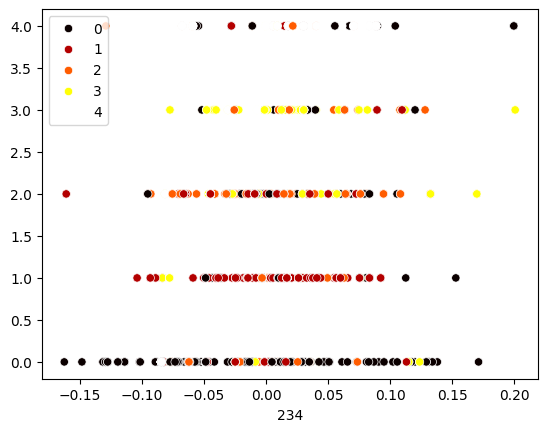

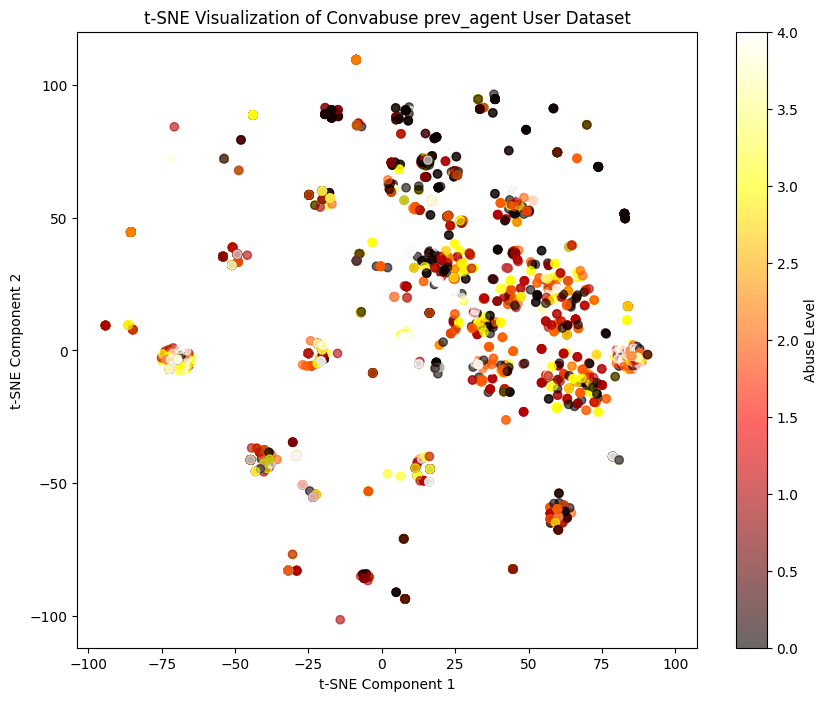

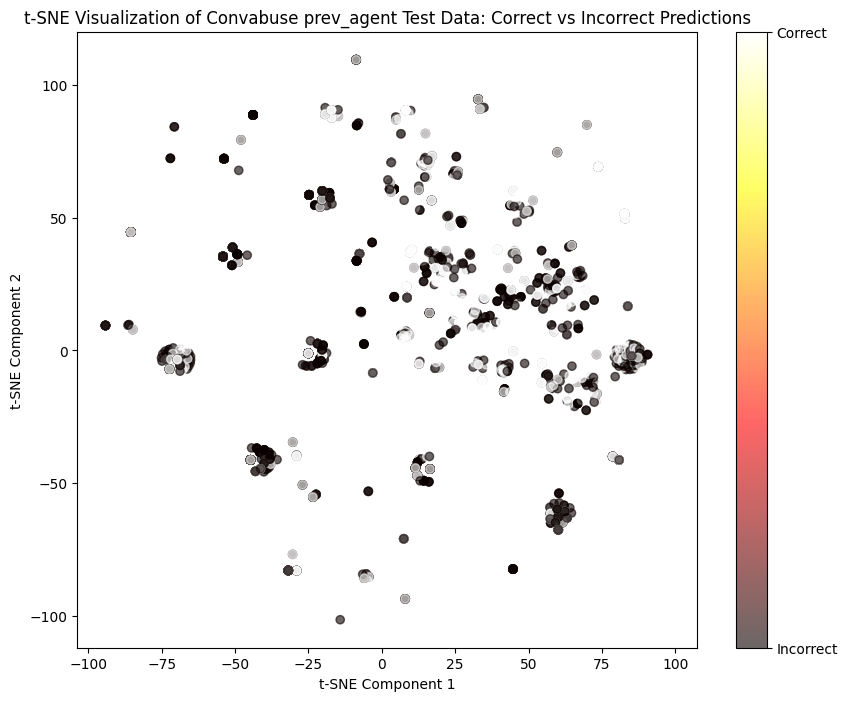

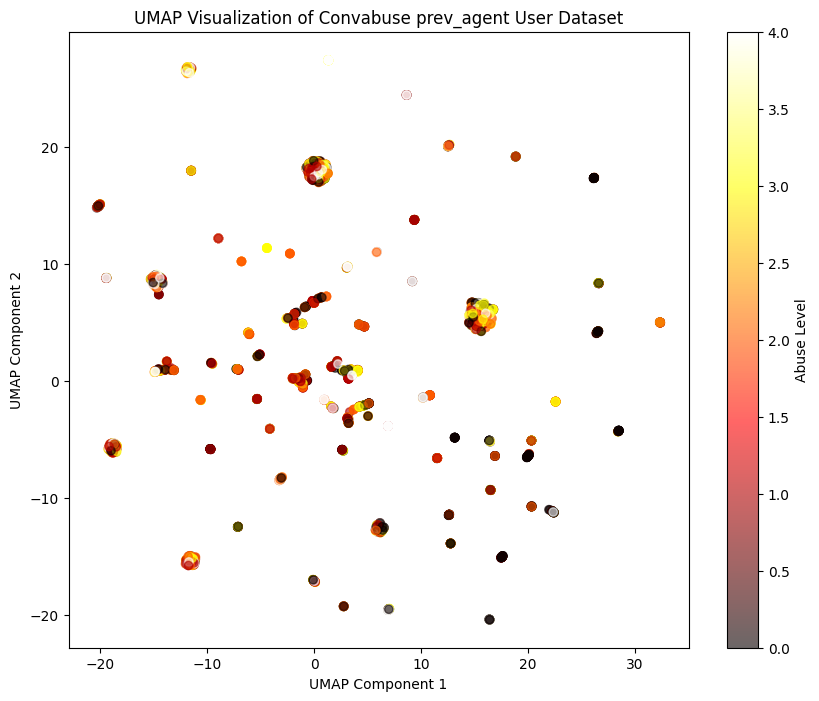

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Convabuse prev_agent,l1,liblinear,0.383025,0.388943,0.0
1,Convabuse prev_agent,l1,saga,0.383423,0.388629,0.0
2,Convabuse prev_agent,l2,lbfgs,0.383423,0.388478,0.0
3,Convabuse prev_agent,l2,liblinear,0.381435,0.386869,0.0
4,Convabuse prev_agent,l2,newton-cg,0.384615,0.390045,0.0
5,Convabuse prev_agent,l2,newton-cholesky,0.385013,0.390574,0.0
6,Convabuse prev_agent,l2,sag,0.385013,0.390574,0.0
7,Convabuse prev_agent,l2,saga,0.385013,0.390574,0.0
8,Convabuse prev_agent,elasticnet,saga,0.383820,0.389246,0.5


In [23]:
convabuse_prev_agent_results_list = logistic_regression_modeling(convabuse_prev_agent_X_train, convabuse_prev_agent_X_test, convabuse_prev_agent_y_train, convabuse_prev_agent_y_test, "Abuse Level", "Convabuse prev_agent")
convabuse_prev_agent_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.5058636453985291, F1-score: 0.5030423745645847
Regularizer: l1, Solver: saga, Accuracy: 0.5072550188829259, F1-score: 0.5049091200338645
Regularizer: l2, Solver: lbfgs, Accuracy: 0.50367720135162, F1-score: 0.5015366778374802
Regularizer: l2, Solver: liblinear, Accuracy: 0.49950308089842976, F1-score: 0.49758181457631895
Regularizer: l2, Solver: newton-cg, Accuracy: 0.5064599483204134, F1-score: 0.5040365614288047
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.5058636453985291, F1-score: 0.5034598036760025
Regularizer: l2, Solver: sag, Accuracy: 0.5058636453985291, F1-score: 0.5034598036760025
Regularizer: l2, Solver: saga, Accuracy: 0.5058636453985291, F1-score: 0.5034598036760025
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.5076525541641821, F1-score: 0.5055991502346133


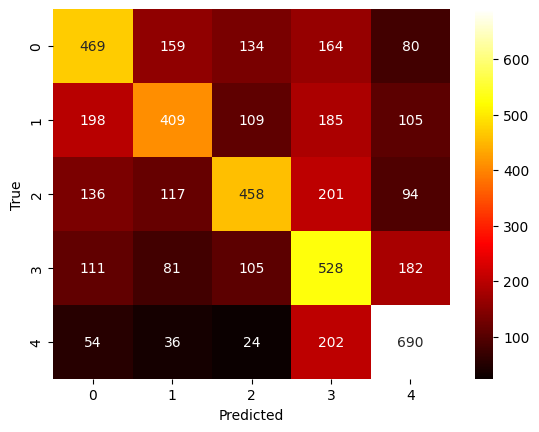

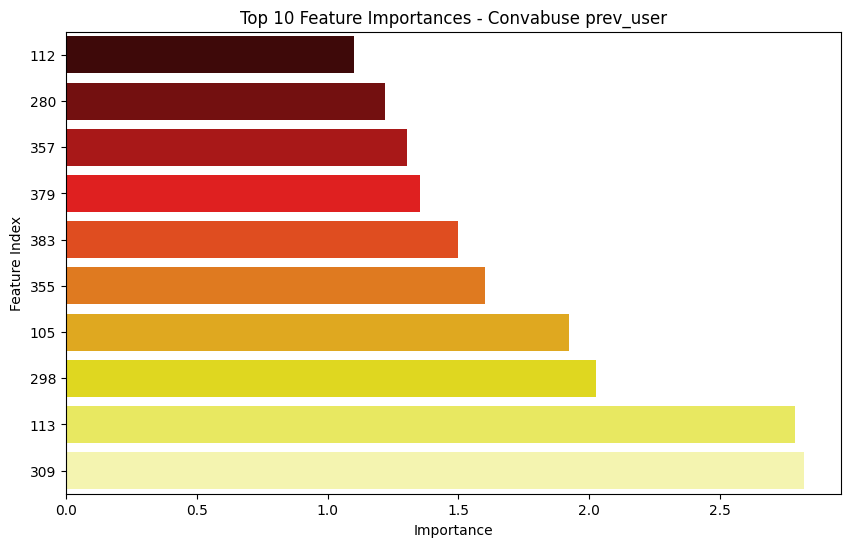

Top 10 Feature Importances
{np.int64(112): np.float32(1.100732), np.int64(280): np.float32(1.2198821), np.int64(357): np.float32(1.3024712), np.int64(379): np.float32(1.3525298), np.int64(383): np.float32(1.4979277), np.int64(355): np.float32(1.6034914), np.int64(105): np.float32(1.9210865), np.int64(298): np.float32(2.0258932), np.int64(113): np.float32(2.7875457), np.int64(309): np.float32(2.8200877)}
Linear Coefficients
{0: np.float32(0.6713856), 1: np.float32(-0.13850605), 2: np.float32(-0.99839175), 3: np.float32(0.012781501), 4: np.float32(-0.81479627), 5: np.float32(0.2714095), 6: np.float32(0.9985049), 7: np.float32(0.99844015), 8: np.float32(-1.1389327), 9: np.float32(0.30967832), 10: np.float32(0.6525047), 11: np.float32(0.99875045), 12: np.float32(0.8382598), 13: np.float32(-0.9983832), 14: np.float32(-0.42732686), 15: np.float32(-1.3458352), 16: np.float32(-0.004220605), 17: np.float32(0.39149475), 18: np.float32(-0.99888), 19: np.float32(0.34433493), 20: np.float32(-0.9746

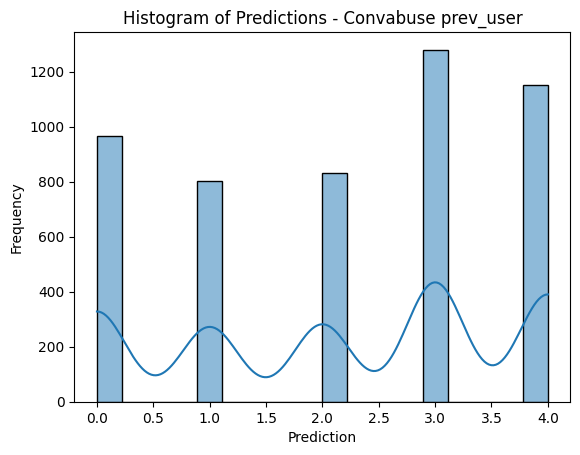

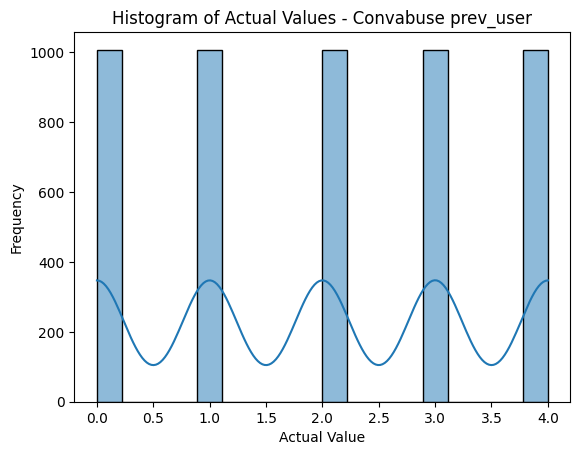

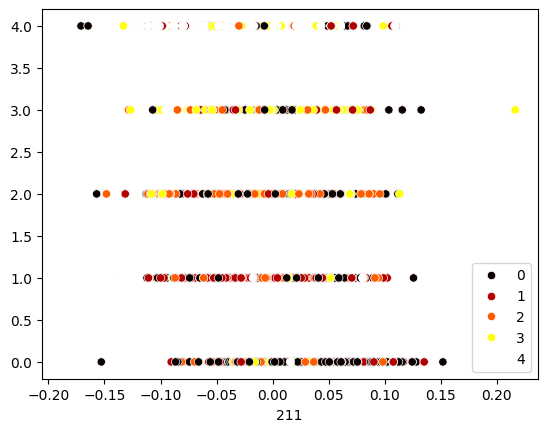

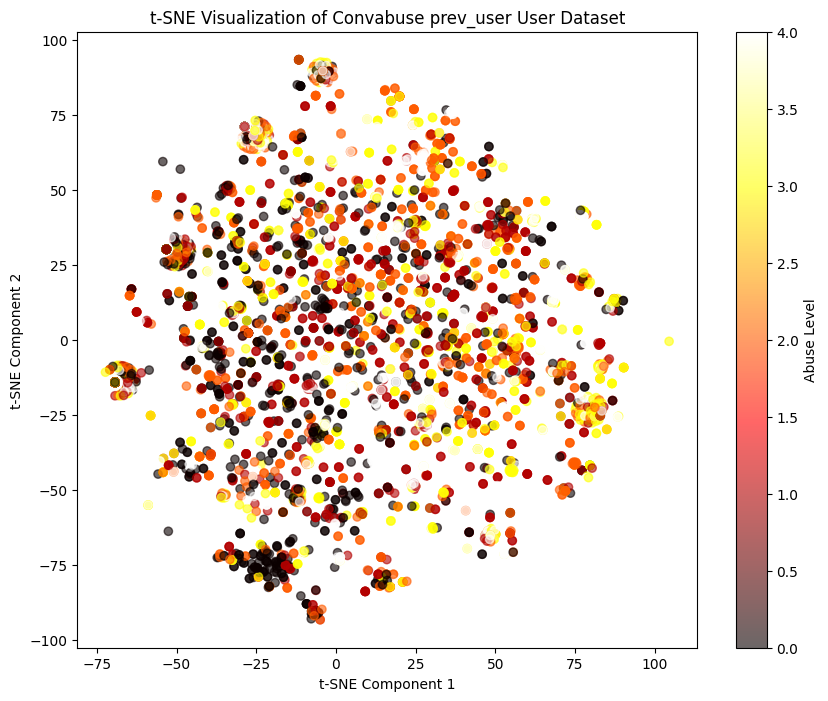

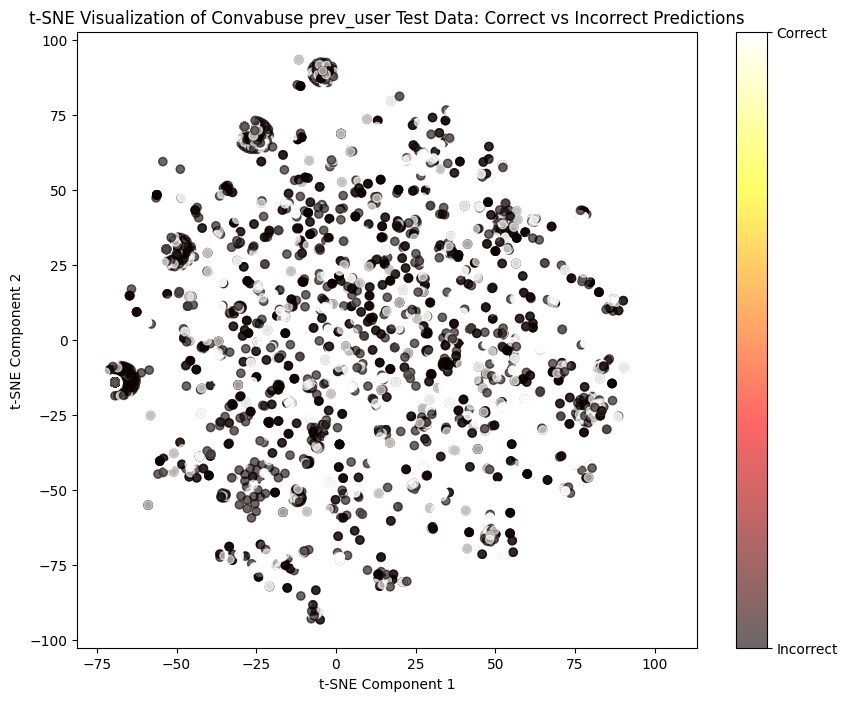

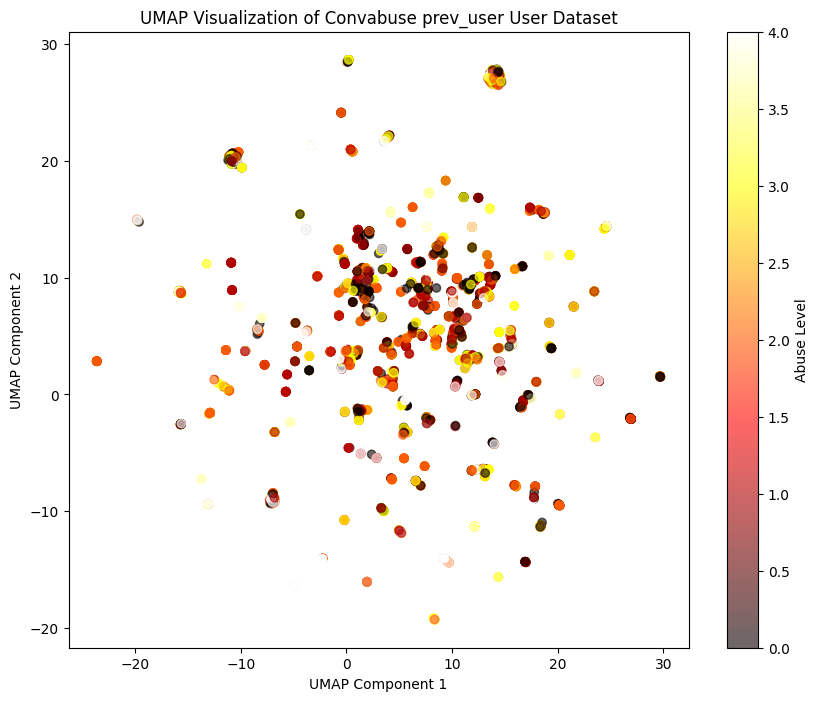

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Convabuse prev_user,l1,liblinear,0.505864,0.503042,0.0
1,Convabuse prev_user,l1,saga,0.507255,0.504909,0.0
2,Convabuse prev_user,l2,lbfgs,0.503677,0.501537,0.0
3,Convabuse prev_user,l2,liblinear,0.499503,0.497582,0.0
4,Convabuse prev_user,l2,newton-cg,0.506460,0.504037,0.0
5,Convabuse prev_user,l2,newton-cholesky,0.505864,0.503460,0.0
6,Convabuse prev_user,l2,sag,0.505864,0.503460,0.0
7,Convabuse prev_user,l2,saga,0.505864,0.503460,0.0
8,Convabuse prev_user,elasticnet,saga,0.507653,0.505599,0.5


In [24]:
convabuse_prev_user_results_list = logistic_regression_modeling(convabuse_prev_user_X_train, convabuse_prev_user_X_test, convabuse_prev_user_y_train, convabuse_prev_user_y_test, "Abuse Level", "Convabuse prev_user")
convabuse_prev_user_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.4054859868813357, F1-score: 0.4016240322981319
Regularizer: l1, Solver: saga, Accuracy: 0.40747366328761675, F1-score: 0.40348063328470524
Regularizer: l2, Solver: lbfgs, Accuracy: 0.40290200755317035, F1-score: 0.3991564389592736
Regularizer: l2, Solver: liblinear, Accuracy: 0.3993241900218644, F1-score: 0.3950070305886687
Regularizer: l2, Solver: newton-cg, Accuracy: 0.4038958457563109, F1-score: 0.4003371818990462
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.404094613396939, F1-score: 0.4005412936384082
Regularizer: l2, Solver: sag, Accuracy: 0.404094613396939, F1-score: 0.4005412936384082
Regularizer: l2, Solver: saga, Accuracy: 0.404094613396939, F1-score: 0.4005412936384082
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.4054859868813357, F1-score: 0.4016872376207548


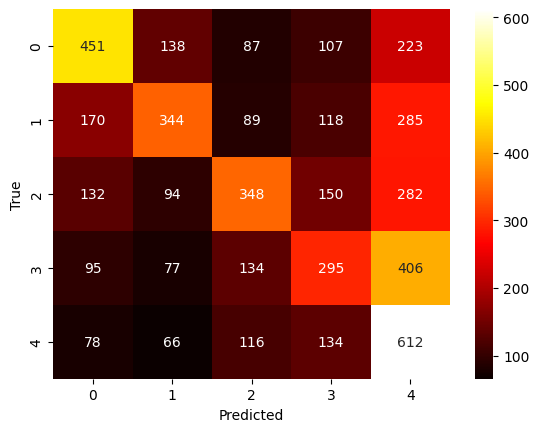

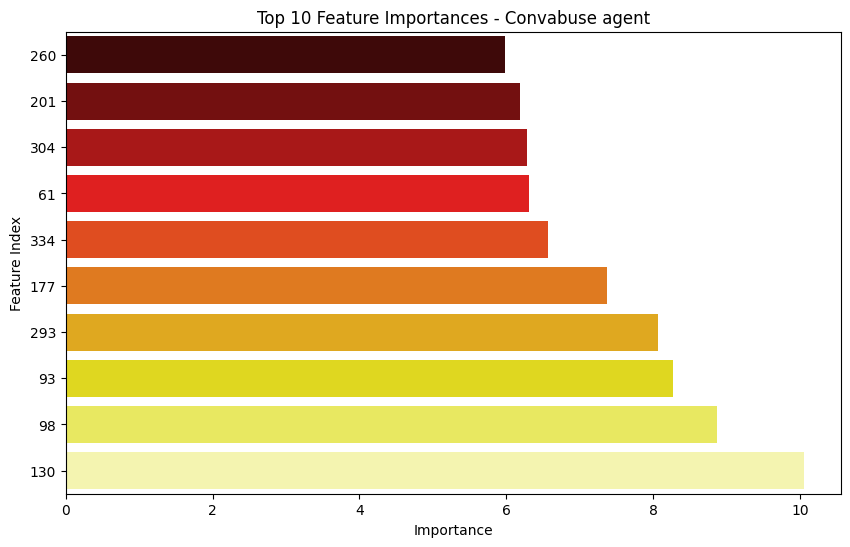

Top 10 Feature Importances
{np.int64(260): np.float32(5.9783435), np.int64(201): np.float32(6.1844807), np.int64(304): np.float32(6.2803507), np.int64(61): np.float32(6.308801), np.int64(334): np.float32(6.561456), np.int64(177): np.float32(7.3669147), np.int64(293): np.float32(8.066888), np.int64(93): np.float32(8.26679), np.int64(98): np.float32(8.874487), np.int64(130): np.float32(10.050251)}
Linear Coefficients
{0: np.float32(0.0), 1: np.float32(-2.5301833), 2: np.float32(3.5145168), 3: np.float32(-1.9157908), 4: np.float32(1.5872674), 5: np.float32(0.0), 6: np.float32(2.7283006), 7: np.float32(0.0), 8: np.float32(-0.16351527), 9: np.float32(0.0), 10: np.float32(-0.054210663), 11: np.float32(2.958497), 12: np.float32(0.0), 13: np.float32(-1.6251309), 14: np.float32(0.90050876), 15: np.float32(1.4194736), 16: np.float32(0.0), 17: np.float32(-0.27086878), 18: np.float32(-1.3069416), 19: np.float32(-10.857397), 20: np.float32(-7.0692253), 21: np.float32(1.4459765), 22: np.float32(-1.9

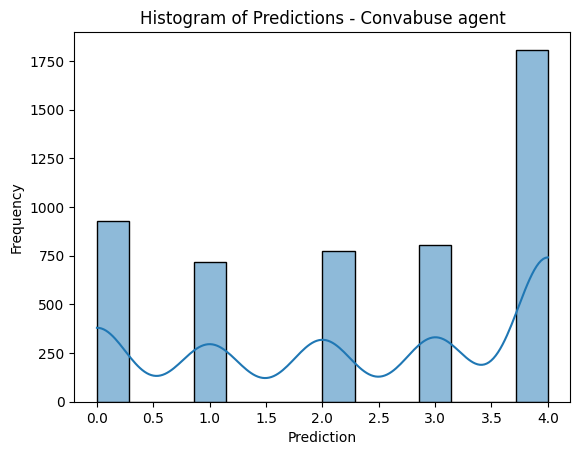

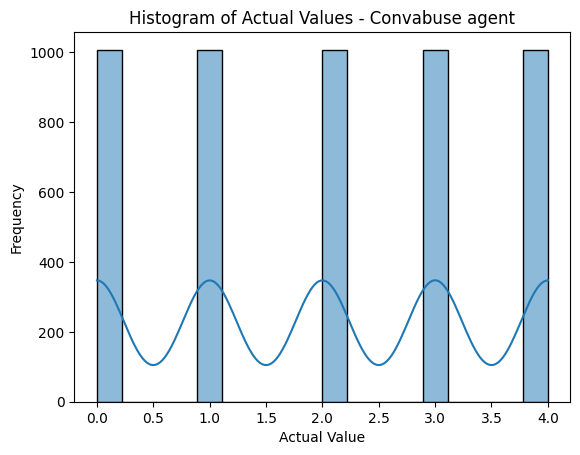

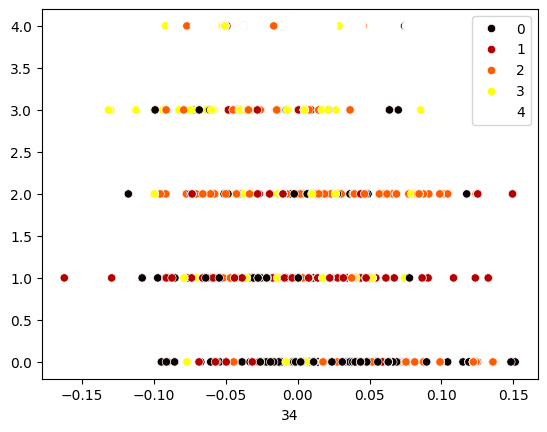

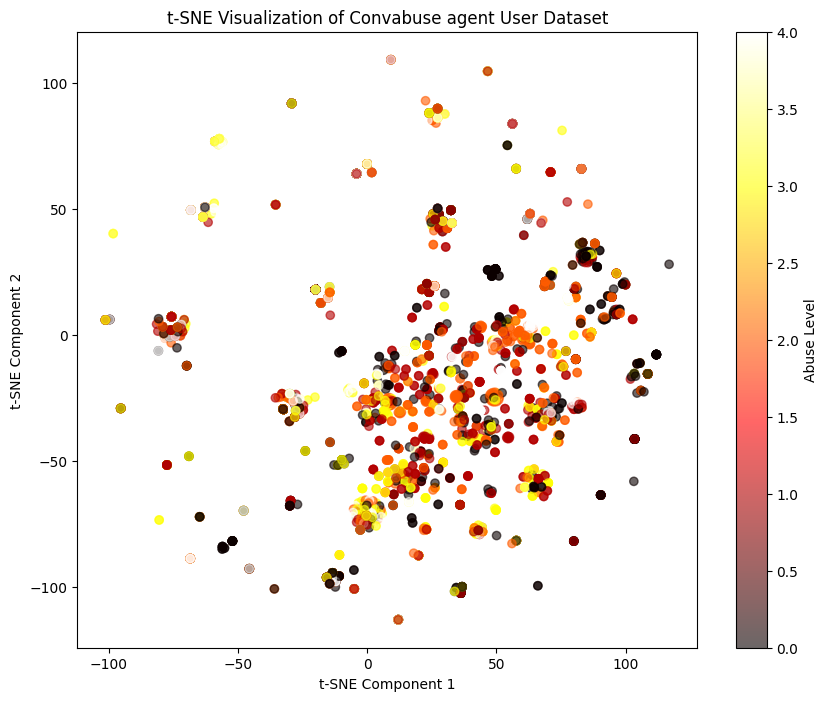

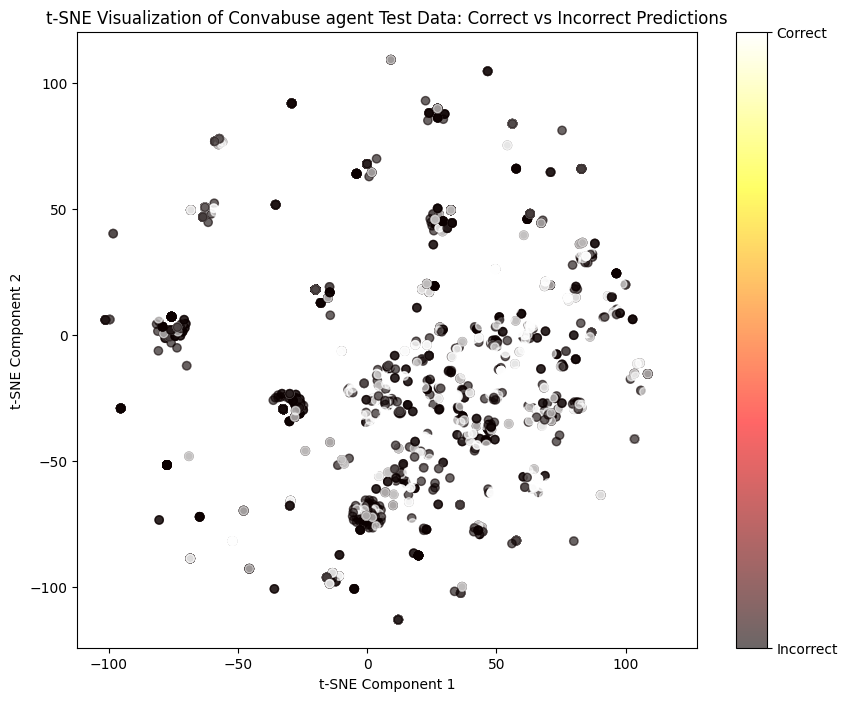

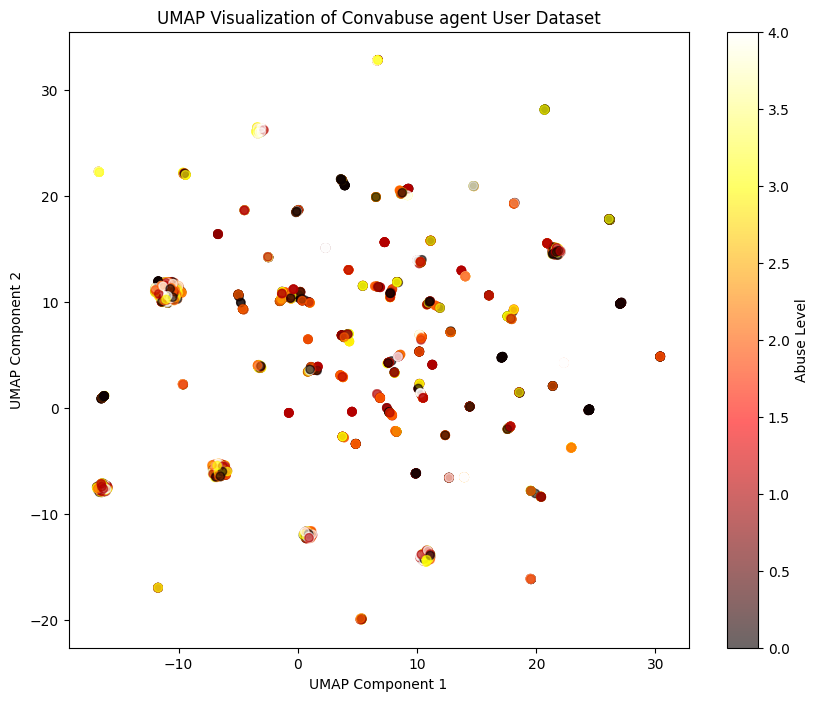

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Convabuse agent,l1,liblinear,0.405486,0.401624,0.0
1,Convabuse agent,l1,saga,0.407474,0.403481,0.0
2,Convabuse agent,l2,lbfgs,0.402902,0.399156,0.0
3,Convabuse agent,l2,liblinear,0.399324,0.395007,0.0
4,Convabuse agent,l2,newton-cg,0.403896,0.400337,0.0
5,Convabuse agent,l2,newton-cholesky,0.404095,0.400541,0.0
6,Convabuse agent,l2,sag,0.404095,0.400541,0.0
7,Convabuse agent,l2,saga,0.404095,0.400541,0.0
8,Convabuse agent,elasticnet,saga,0.405486,0.401687,0.5


In [25]:
convabuse_agent_results_list = logistic_regression_modeling(convabuse_agent_X_train, convabuse_agent_X_test, convabuse_agent_y_train, convabuse_agent_y_test, "Abuse Level", "Convabuse agent")
convabuse_agent_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.6577221228384019, F1-score: 0.6546733771585144
Regularizer: l1, Solver: saga, Accuracy: 0.6700457165573445, F1-score: 0.6679634510558764
Regularizer: l2, Solver: lbfgs, Accuracy: 0.661498708010336, F1-score: 0.6593156283407166
Regularizer: l2, Solver: liblinear, Accuracy: 0.6453985291194594, F1-score: 0.6422811448461895
Regularizer: l2, Solver: newton-cg, Accuracy: 0.6624925462134764, F1-score: 0.6604850144032771
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.6628900814947326, F1-score: 0.6608578364311053
Regularizer: l2, Solver: sag, Accuracy: 0.6628900814947326, F1-score: 0.6608578364311053
Regularizer: l2, Solver: saga, Accuracy: 0.6628900814947326, F1-score: 0.6608578364311053
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.6676605048698072, F1-score: 0.6656978607415764


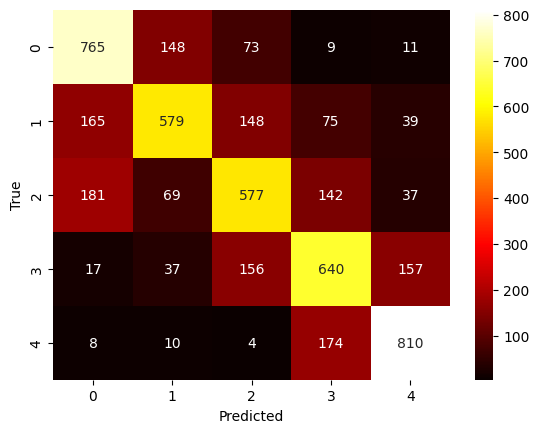

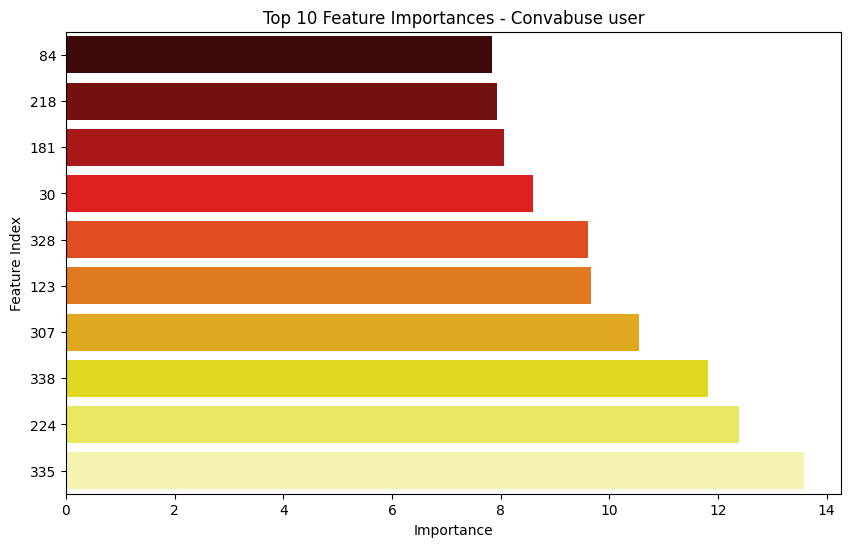

Top 10 Feature Importances
{np.int64(84): np.float32(7.8413286), np.int64(218): np.float32(7.939616), np.int64(181): np.float32(8.059157), np.int64(30): np.float32(8.599768), np.int64(328): np.float32(9.606559), np.int64(123): np.float32(9.661013), np.int64(307): np.float32(10.542812), np.int64(338): np.float32(11.821621), np.int64(224): np.float32(12.390681), np.int64(335): np.float32(13.582134)}
Linear Coefficients
{0: np.float32(-0.4547009), 1: np.float32(0.18547058), 2: np.float32(0.712479), 3: np.float32(0.23657624), 4: np.float32(1.476332), 5: np.float32(1.3983188), 6: np.float32(0.38969398), 7: np.float32(0.715347), 8: np.float32(-0.87758565), 9: np.float32(-3.6972756), 10: np.float32(1.8786898), 11: np.float32(1.0558956), 12: np.float32(-0.94123363), 13: np.float32(-2.4975872), 14: np.float32(-7.285836), 15: np.float32(1.5935175), 16: np.float32(-3.116866), 17: np.float32(1.9813147), 18: np.float32(2.6258917), 19: np.float32(7.5972548), 20: np.float32(-0.0042152517), 21: np.flo

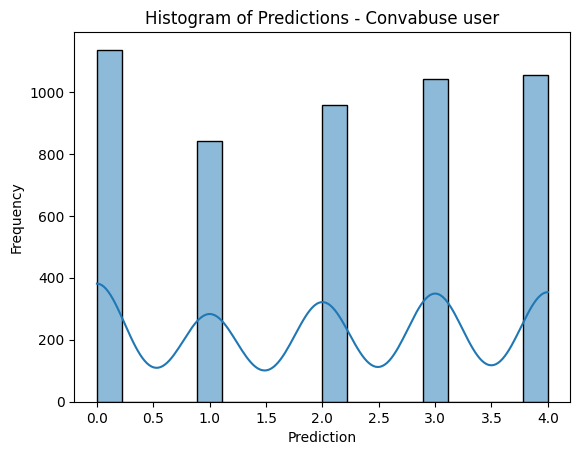

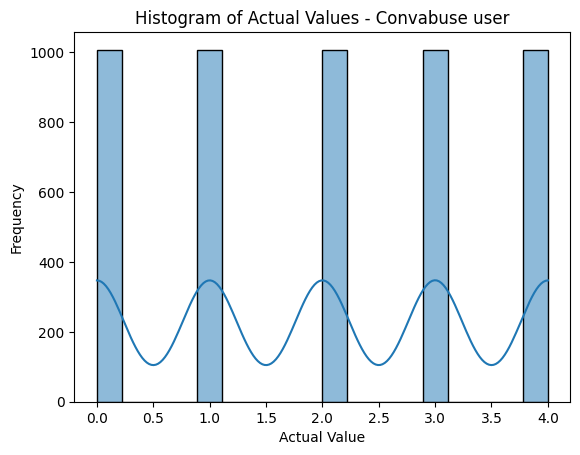

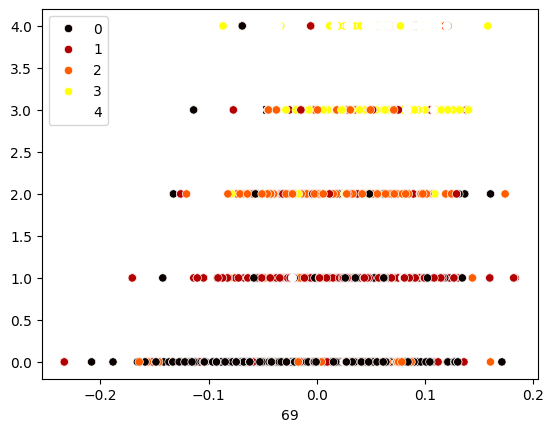

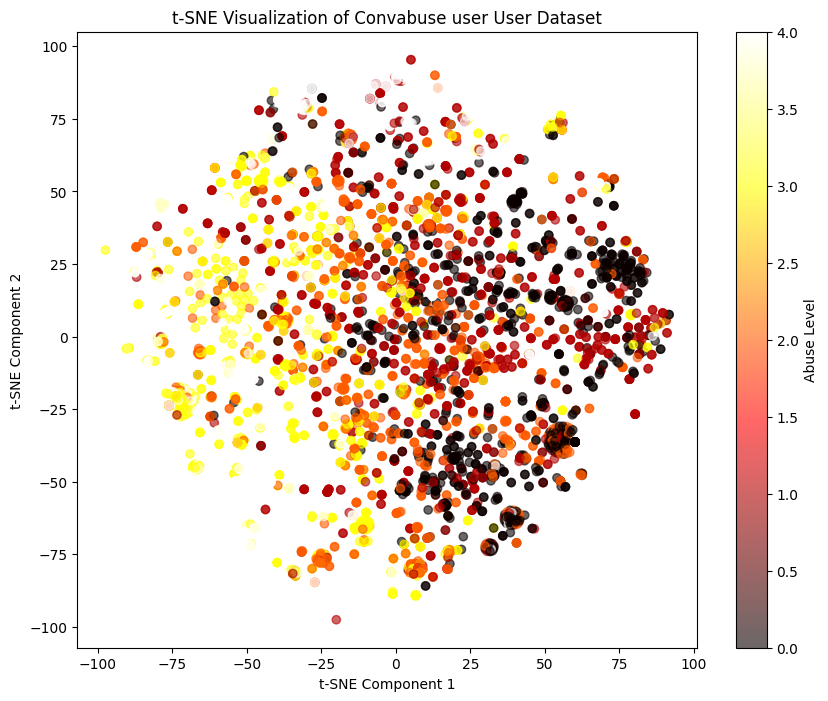

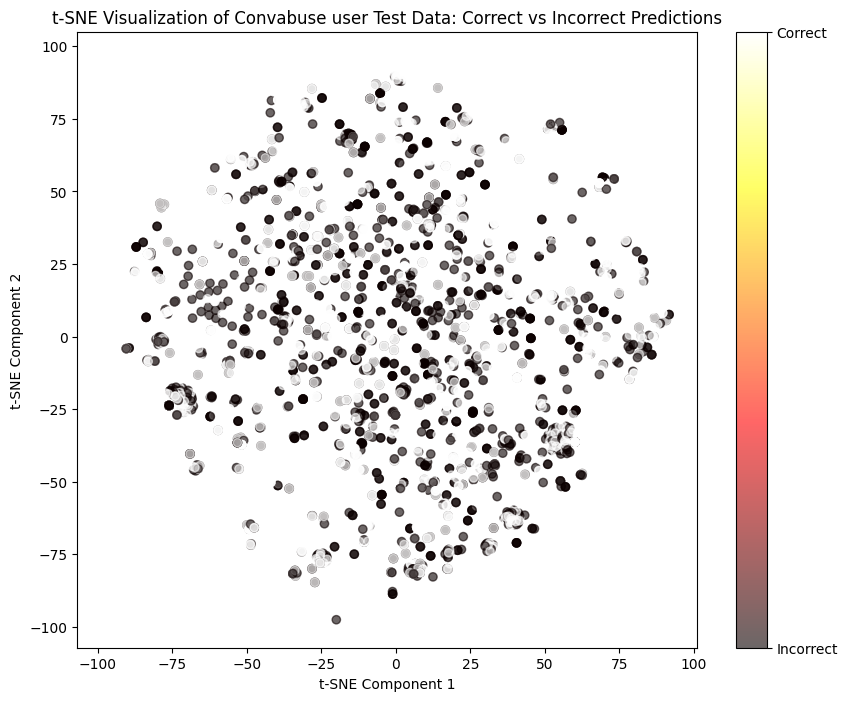

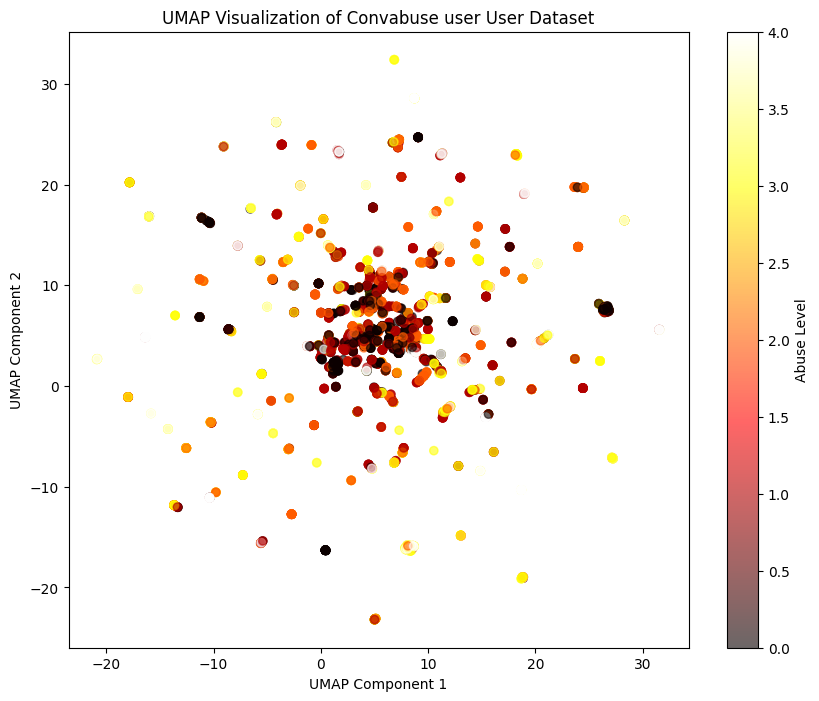

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Convabuse user,l1,liblinear,0.657722,0.654673,0.0
1,Convabuse user,l1,saga,0.670046,0.667963,0.0
2,Convabuse user,l2,lbfgs,0.661499,0.659316,0.0
3,Convabuse user,l2,liblinear,0.645399,0.642281,0.0
4,Convabuse user,l2,newton-cg,0.662493,0.660485,0.0
5,Convabuse user,l2,newton-cholesky,0.662890,0.660858,0.0
6,Convabuse user,l2,sag,0.662890,0.660858,0.0
7,Convabuse user,l2,saga,0.662890,0.660858,0.0
8,Convabuse user,elasticnet,saga,0.667661,0.665698,0.5


In [26]:
convabuse_user_results_list = logistic_regression_modeling(convabuse_user_X_train, convabuse_user_X_test, convabuse_user_y_train, convabuse_user_y_test, "Abuse Level", "Convabuse user")
convabuse_user_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.7845282024248814, F1-score: 0.7418922522786504
Regularizer: l1, Solver: saga, Accuracy: 0.7846599894570374, F1-score: 0.7421109623724248
Regularizer: l2, Solver: lbfgs, Accuracy: 0.7818924617817606, F1-score: 0.7349232889370684
Regularizer: l2, Solver: liblinear, Accuracy: 0.783342119135477, F1-score: 0.7370093704043265
Regularizer: l2, Solver: newton-cg, Accuracy: 0.7834739061676331, F1-score: 0.7371046610706398
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.7836056931997891, F1-score: 0.7373293103430073
Regularizer: l2, Solver: sag, Accuracy: 0.7834739061676331, F1-score: 0.7371046610706398
Regularizer: l2, Solver: saga, Accuracy: 0.7834739061676331, F1-score: 0.7371046610706398
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.7841328413284133, F1-score: 0.7399990251924786


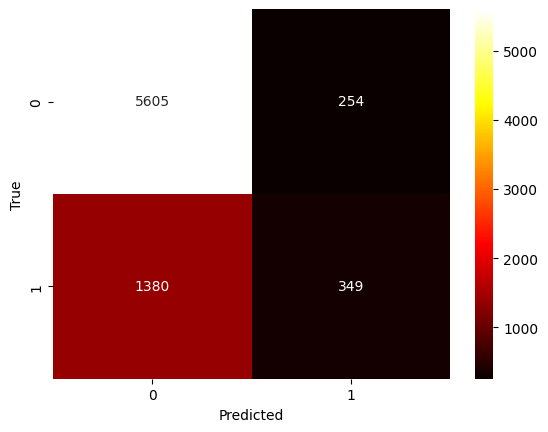

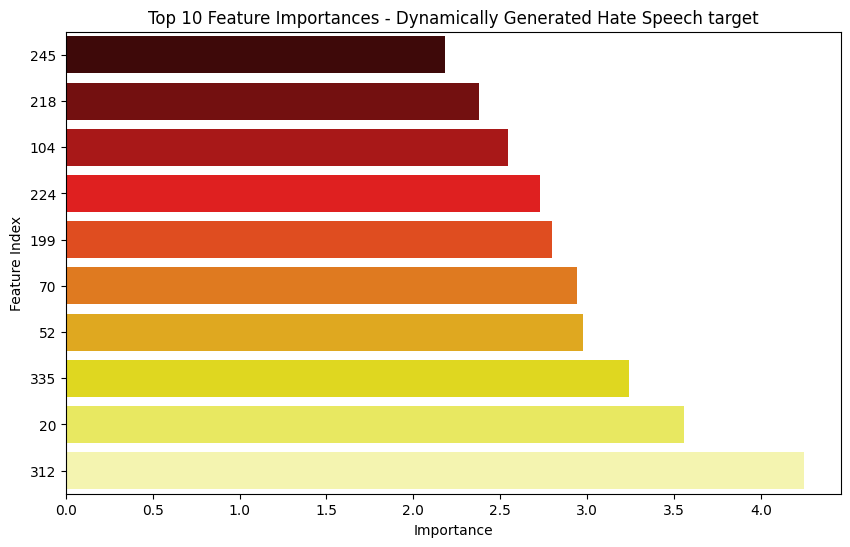

Top 10 Feature Importances
{np.int64(245): np.float32(2.1816902), np.int64(218): np.float32(2.3777072), np.int64(104): np.float32(2.5439544), np.int64(224): np.float32(2.7305984), np.int64(199): np.float32(2.7963736), np.int64(70): np.float32(2.9439511), np.int64(52): np.float32(2.9746737), np.int64(335): np.float32(3.242759), np.int64(20): np.float32(3.5605223), np.int64(312): np.float32(4.248555)}
Linear Coefficients
{0: np.float32(-0.08345437), 1: np.float32(-1.1213301), 2: np.float32(-1.4285604), 3: np.float32(-1.2148144), 4: np.float32(0.0), 5: np.float32(0.0), 6: np.float32(0.0), 7: np.float32(-1.4767303), 8: np.float32(0.0), 9: np.float32(0.9473045), 10: np.float32(-2.266746), 11: np.float32(0.4177658), 12: np.float32(0.27244276), 13: np.float32(0.0), 14: np.float32(-2.689086), 15: np.float32(0.0), 16: np.float32(-0.38715866), 17: np.float32(-1.0209513), 18: np.float32(-0.54120165), 19: np.float32(0.29233167), 20: np.float32(3.5605223), 21: np.float32(1.0563527), 22: np.float32(

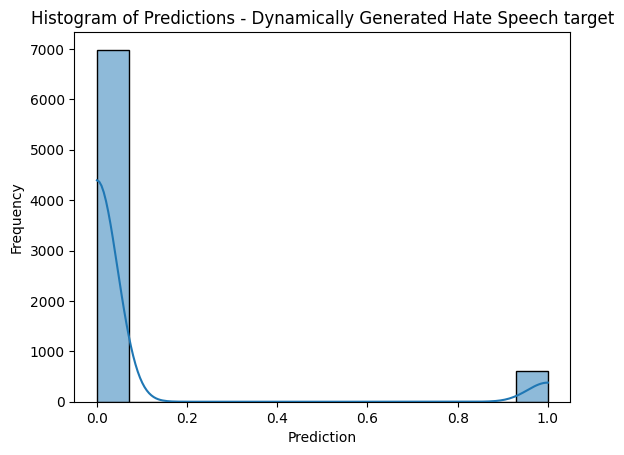

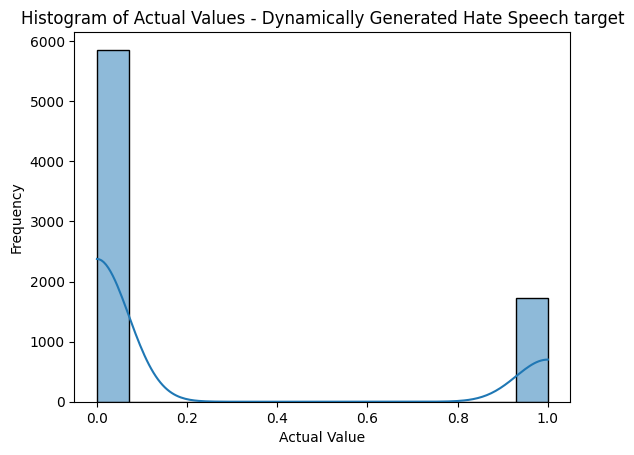

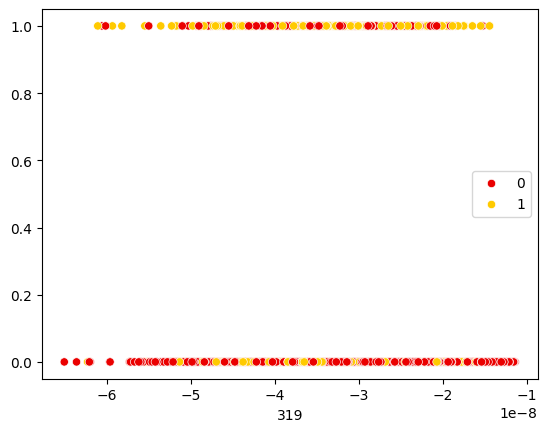

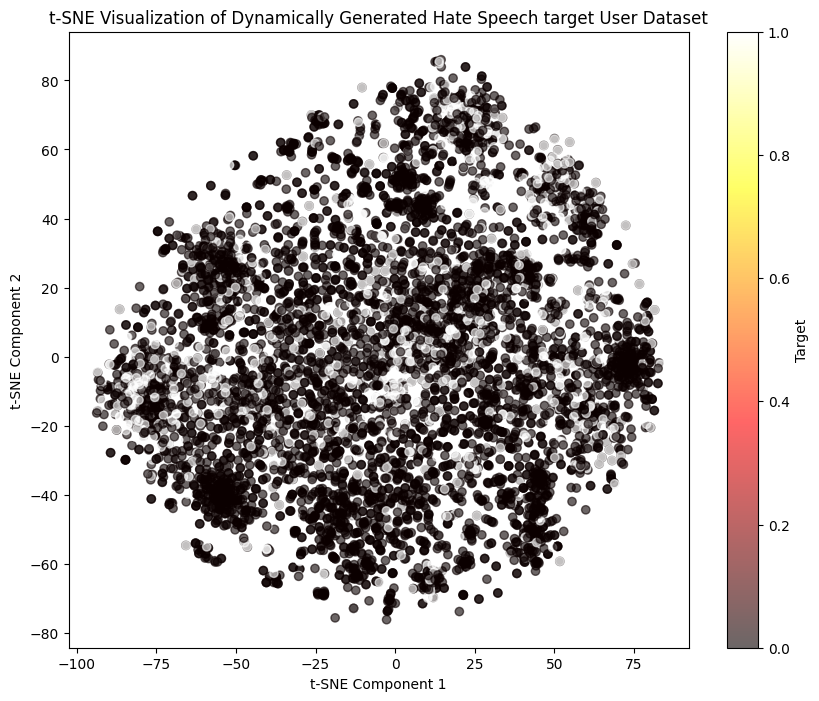

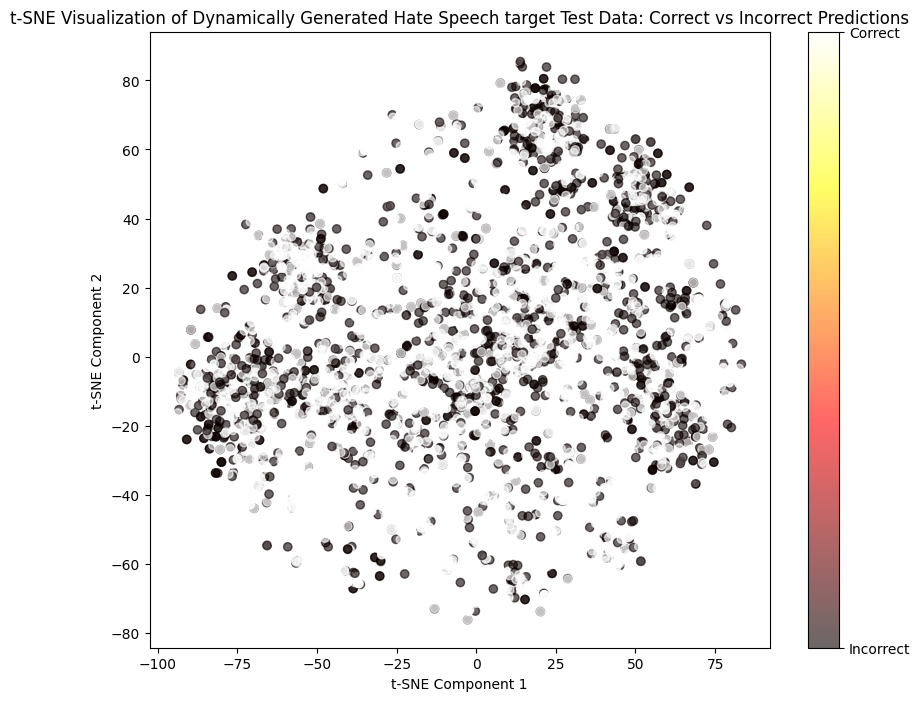

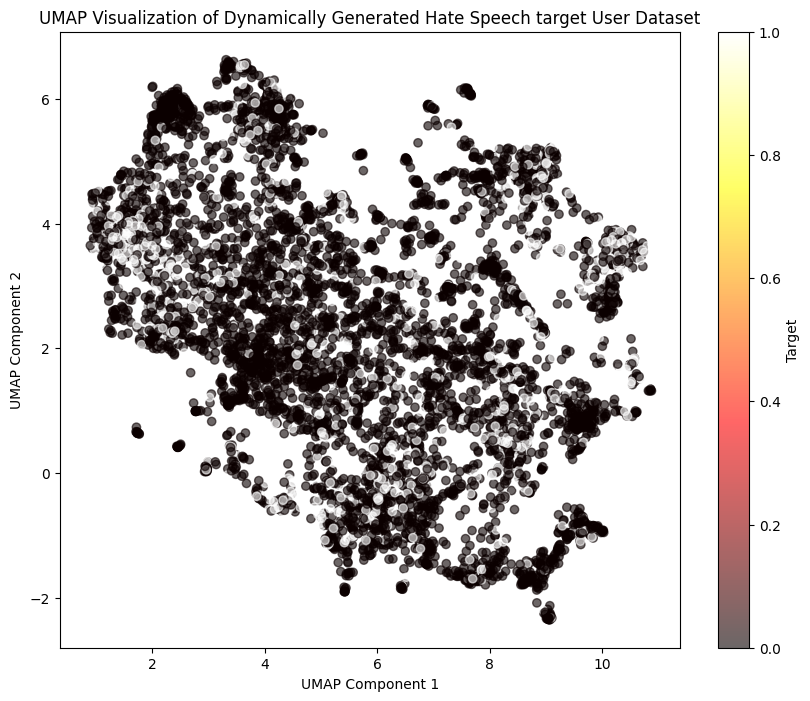

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Dynamically Generated Hate Speech target,l1,liblinear,0.784528,0.741892,0.0
1,Dynamically Generated Hate Speech target,l1,saga,0.784660,0.742111,0.0
2,Dynamically Generated Hate Speech target,l2,lbfgs,0.781892,0.734923,0.0
3,Dynamically Generated Hate Speech target,l2,liblinear,0.783342,0.737009,0.0
4,Dynamically Generated Hate Speech target,l2,newton-cg,0.783474,0.737105,0.0
5,Dynamically Generated Hate Speech target,l2,newton-cholesky,0.783606,0.737329,0.0
6,Dynamically Generated Hate Speech target,l2,sag,0.783474,0.737105,0.0
7,Dynamically Generated Hate Speech target,l2,saga,0.783474,0.737105,0.0
8,Dynamically Generated Hate Speech target,elasticnet,saga,0.784133,0.739999,0.5


In [27]:
dghs_target_results_list = logistic_regression_modeling(dynamically_generated_hate_speech_target_X_train, dynamically_generated_hate_speech_target_X_test, dynamically_generated_hate_speech_target_y_train, dynamically_generated_hate_speech_target_y_test, "Target", "Dynamically Generated Hate Speech target")
dghs_target_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.7038745387453874, F1-score: 0.7038440424363901
Regularizer: l1, Solver: saga, Accuracy: 0.7038745387453874, F1-score: 0.7038440424363901
Regularizer: l2, Solver: lbfgs, Accuracy: 0.7055877701634159, F1-score: 0.7055386538456861
Regularizer: l2, Solver: liblinear, Accuracy: 0.7066420664206642, F1-score: 0.7065826264355676
Regularizer: l2, Solver: newton-cg, Accuracy: 0.7063784923563521, F1-score: 0.7063211824486556
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.7066420664206642, F1-score: 0.7065826264355676
Regularizer: l2, Solver: sag, Accuracy: 0.7066420664206642, F1-score: 0.7065826264355676
Regularizer: l2, Solver: saga, Accuracy: 0.7066420664206642, F1-score: 0.7065826264355676
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.7049288350026357, F1-score: 0.7048900407198693


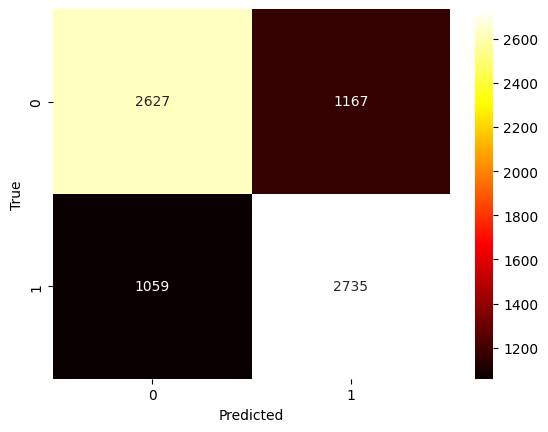

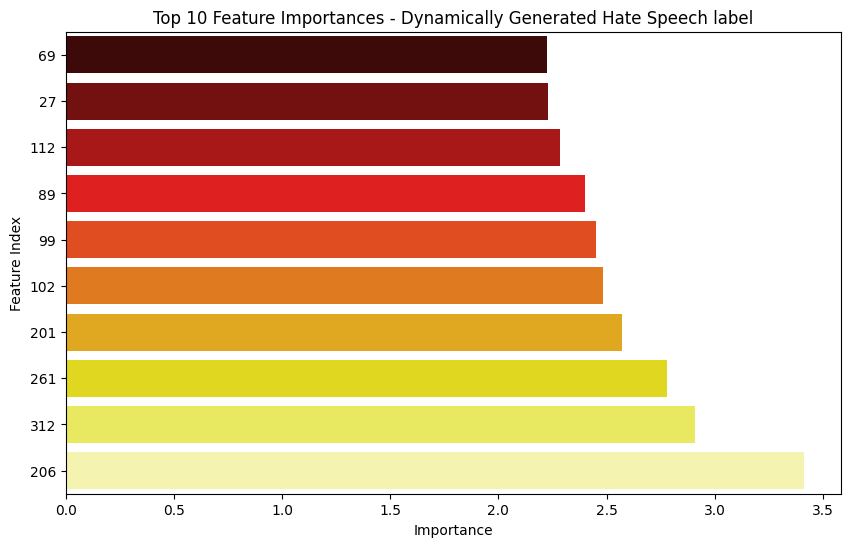

Top 10 Feature Importances
{np.int64(69): np.float64(2.2266035116628053), np.int64(27): np.float64(2.2283292919663715), np.int64(112): np.float64(2.2838750228662996), np.int64(89): np.float64(2.398737305165083), np.int64(99): np.float64(2.4532216249697396), np.int64(102): np.float64(2.4824873324323353), np.int64(201): np.float64(2.571711469409307), np.int64(261): np.float64(2.779125273647084), np.int64(312): np.float64(2.910211997744202), np.int64(206): np.float64(3.4125173596643865)}
Linear Coefficients
{0: np.float64(-0.817786620984105), 1: np.float64(1.3583910806970527), 2: np.float64(-2.0930206210410702), 3: np.float64(-0.8007016605598013), 4: np.float64(-0.3123058082181277), 5: np.float64(0.16269586296524752), 6: np.float64(1.6583469162203799), 7: np.float64(-2.1604716098496897), 8: np.float64(1.2889542423641056), 9: np.float64(0.25065585042316785), 10: np.float64(0.16229967250191593), 11: np.float64(-0.6592137101888332), 12: np.float64(-0.9722812907055504), 13: np.float64(0.15493

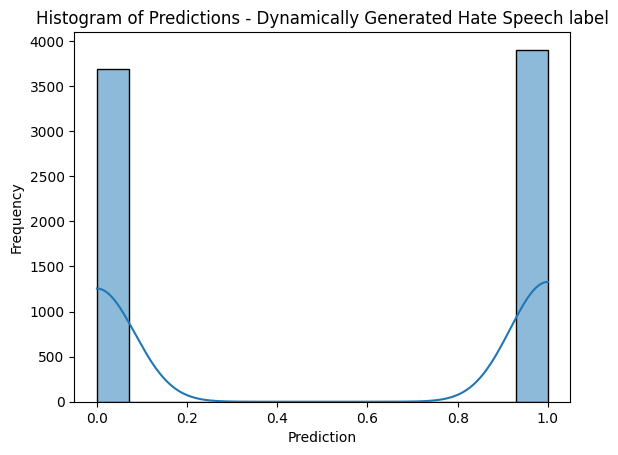

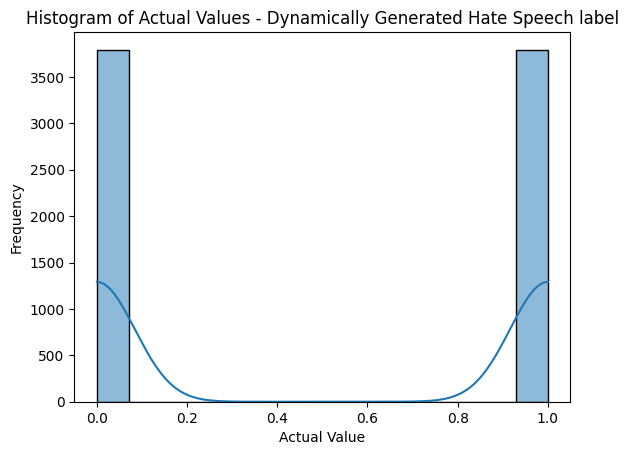

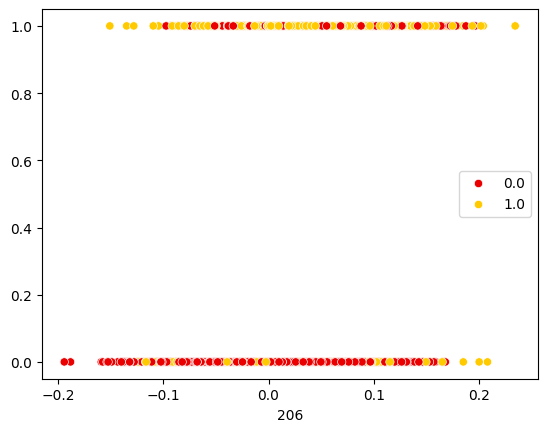

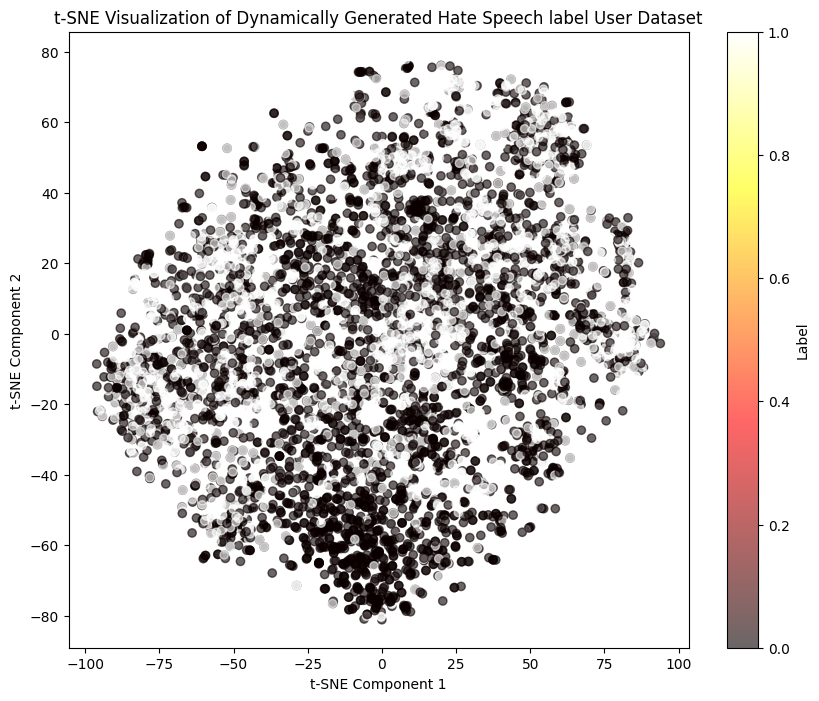

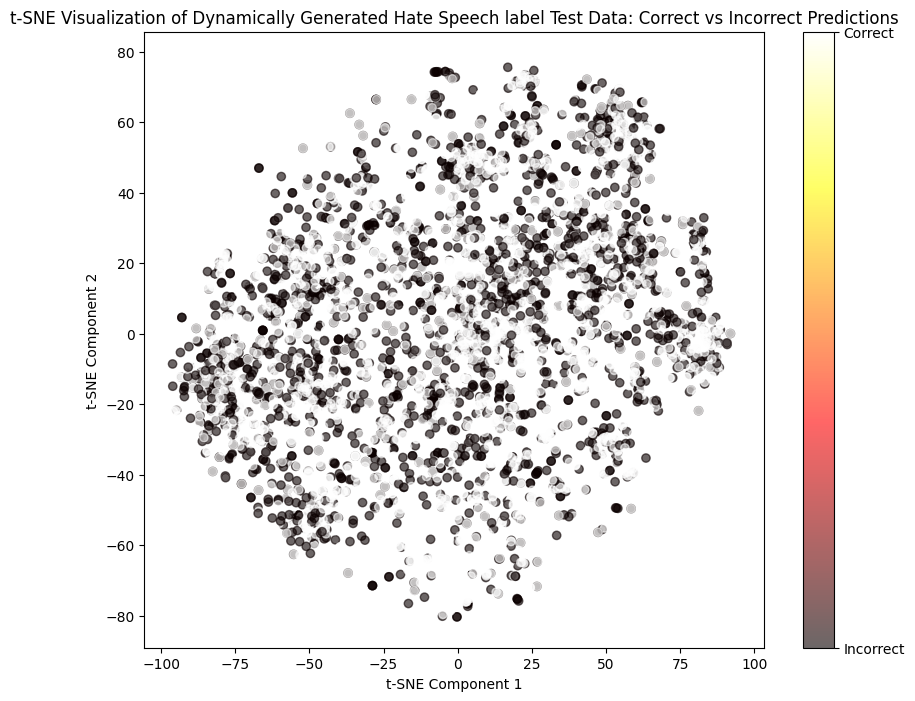

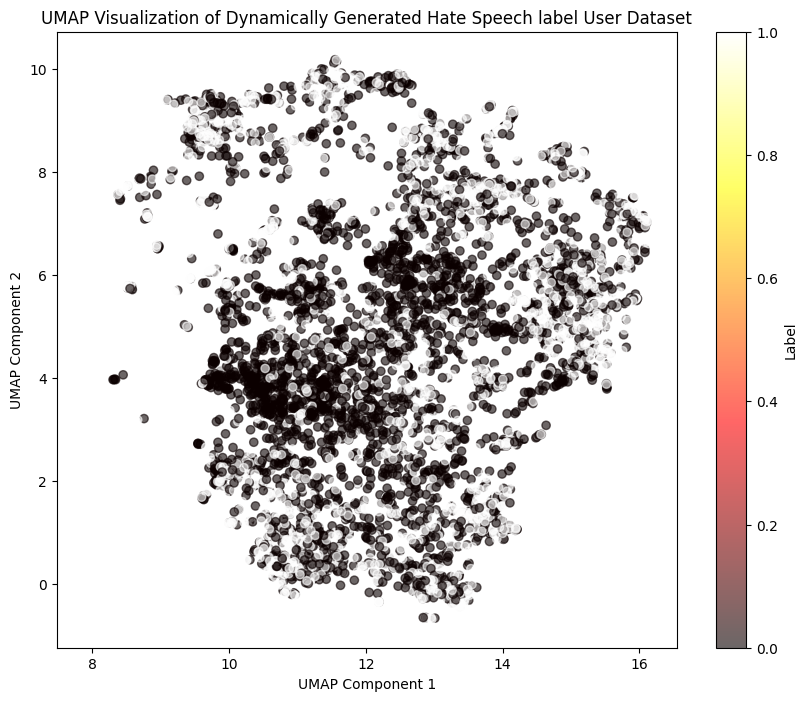

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Dynamically Generated Hate Speech label,l1,liblinear,0.703875,0.703844,0.0
1,Dynamically Generated Hate Speech label,l1,saga,0.703875,0.703844,0.0
2,Dynamically Generated Hate Speech label,l2,lbfgs,0.705588,0.705539,0.0
3,Dynamically Generated Hate Speech label,l2,liblinear,0.706642,0.706583,0.0
4,Dynamically Generated Hate Speech label,l2,newton-cg,0.706378,0.706321,0.0
5,Dynamically Generated Hate Speech label,l2,newton-cholesky,0.706642,0.706583,0.0
6,Dynamically Generated Hate Speech label,l2,sag,0.706642,0.706583,0.0
7,Dynamically Generated Hate Speech label,l2,saga,0.706642,0.706583,0.0
8,Dynamically Generated Hate Speech label,elasticnet,saga,0.704929,0.704890,0.5


In [28]:
dghs_label_results_list = logistic_regression_modeling(dynamically_generated_hate_speech_label_X_train, dynamically_generated_hate_speech_label_X_test, dynamically_generated_hate_speech_label_y_train, dynamically_generated_hate_speech_label_y_test, "Label", "Dynamically Generated Hate Speech label")
dghs_label_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.6848162903939796, F1-score: 0.589841941196912
Regularizer: l1, Solver: saga, Accuracy: 0.6817175741478531, F1-score: 0.5981300828909157
Regularizer: l2, Solver: lbfgs, Accuracy: 0.6839309428950863, F1-score: 0.6033747558153444
Regularizer: l2, Solver: liblinear, Accuracy: 0.6834882691456396, F1-score: 0.5907392959210934
Regularizer: l2, Solver: newton-cg, Accuracy: 0.684373616644533, F1-score: 0.604198995786993
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.684373616644533, F1-score: 0.604198995786993
Regularizer: l2, Solver: sag, Accuracy: 0.684373616644533, F1-score: 0.604198995786993
Regularizer: l2, Solver: saga, Accuracy: 0.684373616644533, F1-score: 0.604198995786993
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.6821602478972997, F1-score: 0.5995945350213682


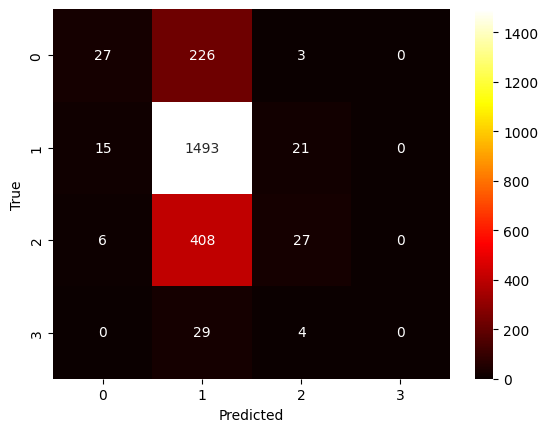

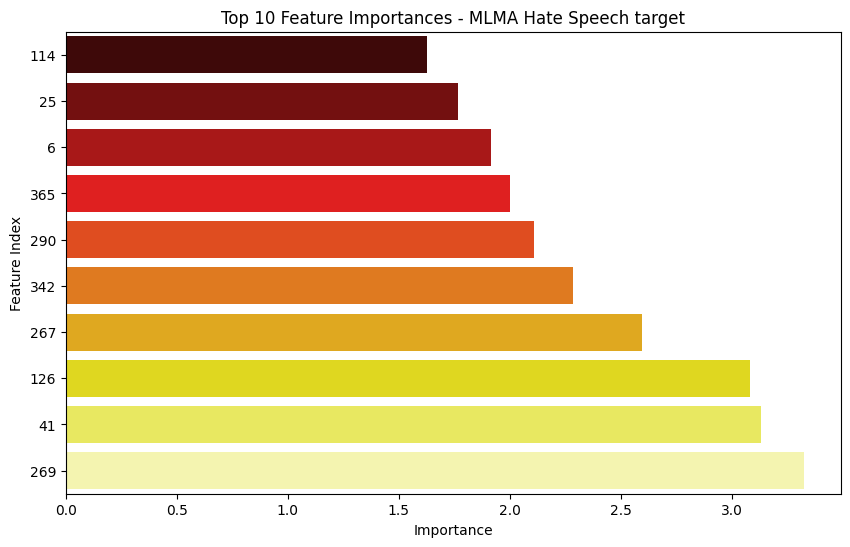

Top 10 Feature Importances
{np.int64(114): np.float64(1.6275796862335092), np.int64(25): np.float64(1.7653421996111467), np.int64(6): np.float64(1.9171269055934164), np.int64(365): np.float64(1.9986449652730753), np.int64(290): np.float64(2.1095231065514706), np.int64(342): np.float64(2.28525574490473), np.int64(267): np.float64(2.5966176900646136), np.int64(126): np.float64(3.0835839420091133), np.int64(41): np.float64(3.130562185117139), np.int64(269): np.float64(3.3245500864634554)}
Linear Coefficients
{0: np.float64(-0.9777227813361502), 1: np.float64(0.5256258743558935), 2: np.float64(0.32308503408002287), 3: np.float64(-0.26918650492620155), 4: np.float64(-0.08628608519029213), 5: np.float64(0.0), 6: np.float64(1.9171269055934164), 7: np.float64(0.0), 8: np.float64(0.04883707357718311), 9: np.float64(0.16569454748642537), 10: np.float64(0.05121774173350739), 11: np.float64(-0.0975078478617485), 12: np.float64(-0.705078395534142), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.f

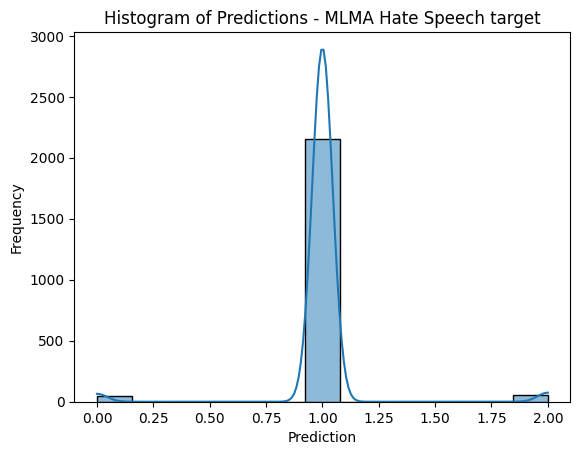

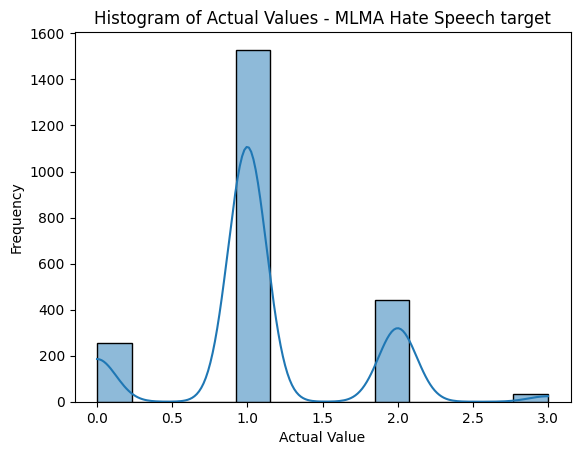

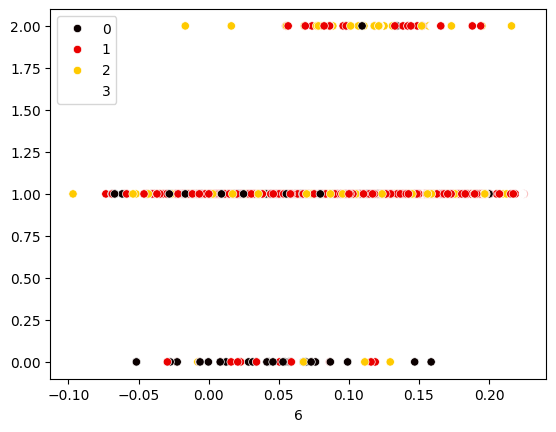

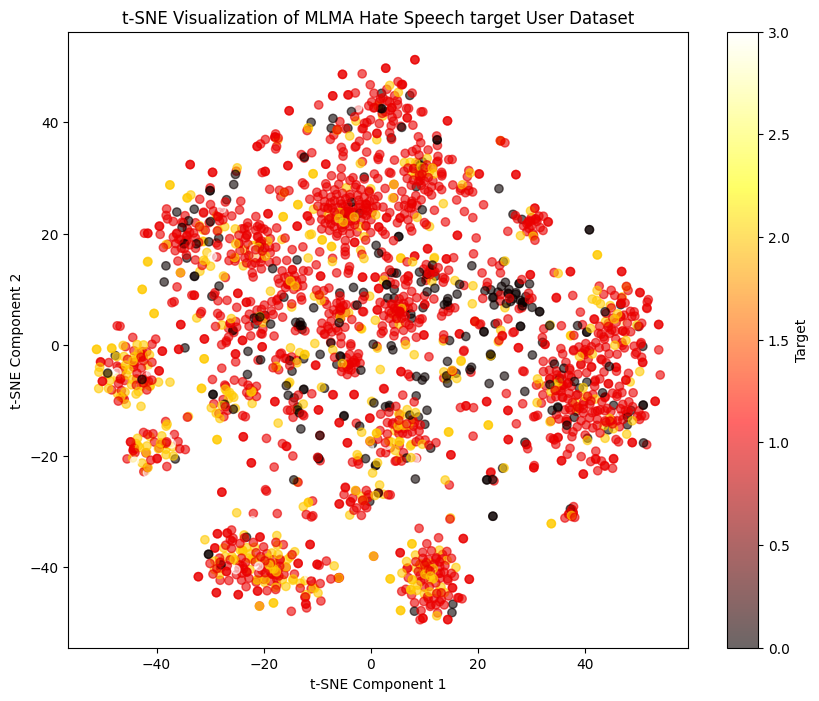

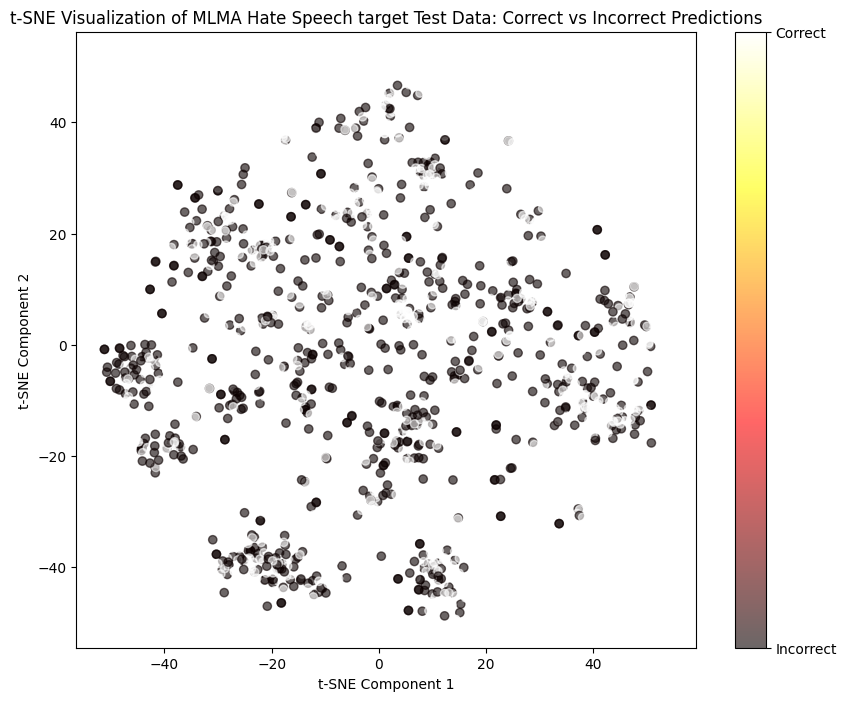

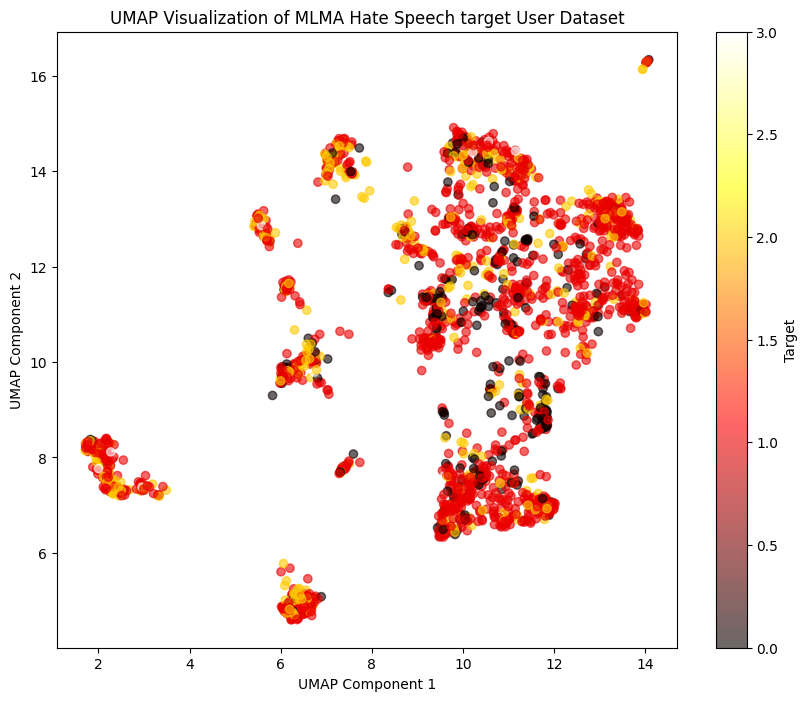

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,MLMA Hate Speech target,l1,liblinear,0.684816,0.589842,0.0
1,MLMA Hate Speech target,l1,saga,0.681718,0.598130,0.0
2,MLMA Hate Speech target,l2,lbfgs,0.683931,0.603375,0.0
3,MLMA Hate Speech target,l2,liblinear,0.683488,0.590739,0.0
4,MLMA Hate Speech target,l2,newton-cg,0.684374,0.604199,0.0
5,MLMA Hate Speech target,l2,newton-cholesky,0.684374,0.604199,0.0
6,MLMA Hate Speech target,l2,sag,0.684374,0.604199,0.0
7,MLMA Hate Speech target,l2,saga,0.684374,0.604199,0.0
8,MLMA Hate Speech target,elasticnet,saga,0.682160,0.599595,0.5


In [29]:
mlma_hate_speech_results_list = logistic_regression_modeling(mlma_hate_speech_target_X_train, mlma_hate_speech_target_X_test, mlma_hate_speech_target_y_train, mlma_hate_speech_target_y_test, "Target", "MLMA Hate Speech target")
mlma_hate_speech_results_list

## Logistic Regression Conclusions

In [30]:
logistic_regression_model_results

[('Convabuse combined',
  Dataset        Convabuse combined
  Regularizer                    l1
  Solver                       saga
  Accuracy                 0.644405
  F1-score                 0.641393
  Ratio                         0.0
  Name: 1, dtype: object,
  0.6444046909163188,
  0.64139333857191,
  0.0,
  {0: np.float32(-0.20279072),
   1: np.float32(-0.69691426),
   2: np.float32(6.02564),
   3: np.float32(0.7752415),
   4: np.float32(-0.9190419),
   5: np.float32(0.57442963),
   6: np.float32(1.5100592),
   7: np.float32(-0.069024324),
   8: np.float32(-1.9242252),
   9: np.float32(5.5978947),
   10: np.float32(0.13597672),
   11: np.float32(0.6698828),
   12: np.float32(3.492198),
   13: np.float32(-0.7387676),
   14: np.float32(-2.7353425),
   15: np.float32(0.8316541),
   16: np.float32(0.7364459),
   17: np.float32(-1.0603037),
   18: np.float32(0.4671576),
   19: np.float32(-1.5296818),
   20: np.float32(-0.05422175),
   21: np.float32(-4.9161735),
   22: np.float32(0.

In [31]:
# Remove the first entry from logistic_regression_model_results
logistic_regression_model_results = logistic_regression_model_results[1:]
logistic_regression_model_results

[('Convabuse combined',
  Dataset        Convabuse combined
  Regularizer                    l1
  Solver                       saga
  Accuracy                 0.644405
  F1-score                 0.641393
  Ratio                         0.0
  Name: 1, dtype: object,
  0.6444046909163188,
  0.64139333857191,
  0.0,
  {0: np.float32(-0.20279072),
   1: np.float32(-0.69691426),
   2: np.float32(6.02564),
   3: np.float32(0.7752415),
   4: np.float32(-0.9190419),
   5: np.float32(0.57442963),
   6: np.float32(1.5100592),
   7: np.float32(-0.069024324),
   8: np.float32(-1.9242252),
   9: np.float32(5.5978947),
   10: np.float32(0.13597672),
   11: np.float32(0.6698828),
   12: np.float32(3.492198),
   13: np.float32(-0.7387676),
   14: np.float32(-2.7353425),
   15: np.float32(0.8316541),
   16: np.float32(0.7364459),
   17: np.float32(-1.0603037),
   18: np.float32(0.4671576),
   19: np.float32(-1.5296818),
   20: np.float32(-0.05422175),
   21: np.float32(-4.9161735),
   22: np.float32(0.

In [32]:
logistic_regression_TSNE

{'Convabuse combined': array([[ 43.30916  , -26.780212 ],
        [ 13.993892 ,  -5.3321266],
        [ 50.137024 ,  11.47899  ],
        ...,
        [-90.56485  , -33.799496 ],
        [-10.688705 , 100.87109  ],
        [ 40.664715 , -73.375824 ]], dtype=float32),
 'Convabuse prev_agent': array([[-18.837997 ,  -0.9881695],
        [ 37.88031  ,   9.758912 ],
        [-21.980087 ,  -4.8347964],
        ...,
        [ 82.61106  ,  51.49551  ],
        [-70.6978   ,  84.2223   ],
        [ 68.42428  ,  28.154173 ]], dtype=float32),
 'Convabuse prev_user': array([[-19.543026  ,  15.332836  ],
        [ -5.211303  ,  -0.24972603],
        [ 54.657696  , -57.581985  ],
        ...,
        [-25.48032   , -75.71298   ],
        [-28.668566  ,  71.22302   ],
        [ -2.2533715 , -33.159206  ]], dtype=float32),
 'Convabuse agent': array([[-14.513985,  16.9218  ],
        [ 60.57173 ,  39.571682],
        [ 19.360933, -10.856189],
        ...,
        [ 46.61506 ,  25.808756],
        [ -4.

In [33]:
logistic_regression_UMAP

{'Convabuse combined': array([[11.606882  ,  1.1595085 ],
        [ 0.2612964 ,  0.93485594],
        [19.438717  , 10.182262  ],
        ...,
        [ 3.580768  , -3.7643833 ],
        [14.956609  , 19.89605   ],
        [-2.6765797 , -9.409313  ]], dtype=float32),
 'Convabuse prev_agent': array([[-3.8708651e-01,  1.8477819e+01],
        [ 4.5722976e+00, -2.1201963e+00],
        [-1.6662600e-02,  1.8189154e+01],
        ...,
        [ 2.6160973e+01,  1.7378963e+01],
        [-1.1741642e+01, -1.5788917e+01],
        [-1.0632439e+01, -1.6088697e+00]], dtype=float32),
 'Convabuse prev_user': array([[ 5.2203116 , -0.94762075],
        [ 4.4072275 ,  1.3340636 ],
        [12.35882   ,  7.738255  ],
        ...,
        [ 2.1282501 ,  8.808111  ],
        [-6.7899685 , -8.866531  ],
        [ 8.62771   , 12.629798  ]], dtype=float32),
 'Convabuse agent': array([[-11.838433  ,  11.096924  ],
        [ -1.3202181 ,  10.970137  ],
        [ 17.920858  ,   8.368315  ],
        ...,
        [ 2

In [34]:
# Pickle both dictionaries
with open(f'{pickle_path}logistic-regression-TSNE-dict_sentiment-analysis-resampled.pkl', 'wb') as f:
    pickle.dump(logistic_regression_TSNE, f)
with open(f'{pickle_path}logistic-regression-UMAP-dict_sentiment-analysis-resampled.pkl', 'wb') as f:
    pickle.dump(logistic_regression_UMAP, f)

In [35]:
logistic_regression_model_summary = pd.DataFrame(logistic_regression_model_results, columns=["Dataset", "Best Parameters", "Accuracy", "F1-score", "Ratio", "Importances", "Feature Importances"])
logistic_regression_model_summary["Balance"] = "Resample"
logistic_regression_model_summary["Model"] = "Logistic Regression"
logistic_regression_model_summary

,Dataset,Best Parameters,Accuracy,F1-score,Ratio,Importances,Feature Importances,Balance,Model
0,Convabuse combined,Dataset Convabuse combined Regularizer ...,0.644405,0.641393,0.0,"{0: -0.20279072, 1: -0.69691426, 2: 6.02564, 3...","{117: 8.011974, 173: 8.084111, 228: 8.3534, 32...",Resample,Logistic Regression
1,Convabuse combined,Dataset Convabuse combined Regularizer ...,0.644405,0.641393,0.0,"{0: -0.20279072, 1: -0.69691426, 2: 6.02564, 3...","{117: 8.011974, 173: 8.084111, 228: 8.3534, 32...",Resample,Logistic Regression
2,Convabuse prev_agent,Dataset Convabuse prev_agent Regularize...,0.385013,0.390574,0.0,"{0: -4.7683716e-07, 1: 1.3113022e-06, 2: -2.73...","{17: 3.349781e-05, 34: 3.4093857e-05, 367: 3.5...",Resample,Logistic Regression
3,Convabuse prev_user,Dataset Convabuse prev_user Regularizer...,0.507653,0.505599,0.0,"{0: 0.6713856, 1: -0.13850605, 2: -0.99839175,...","{112: 1.100732, 280: 1.2198821, 357: 1.3024712...",Resample,Logistic Regression
4,Convabuse agent,Dataset Convabuse agent Regularizer ...,0.407474,0.403481,0.0,"{0: 0.0, 1: -2.5301833, 2: 3.5145168, 3: -1.91...","{260: 5.9783435, 201: 6.1844807, 304: 6.280350...",Resample,Logistic Regression
5,Convabuse user,Dataset Convabuse user Regularizer ...,0.670046,0.667963,0.0,"{0: -0.4547009, 1: 0.18547058, 2: 0.712479, 3:...","{84: 7.8413286, 218: 7.939616, 181: 8.059157, ...",Resample,Logistic Regression
6,Dynamically Generated Hate Speech target,Dataset Dynamically Generated Hate Spee...,0.784660,0.742111,0.0,"{0: -0.08345437, 1: -1.1213301, 2: -1.4285604,...","{245: 2.1816902, 218: 2.3777072, 104: 2.543954...",Resample,Logistic Regression
7,Dynamically Generated Hate Speech label,Dataset Dynamically Generated Hate Spee...,0.706642,0.706583,0.0,"{0: -0.817786620984105, 1: 1.3583910806970527,...","{69: 2.2266035116628053, 27: 2.228329291966371...",Resample,Logistic Regression
8,MLMA Hate Speech target,Dataset MLMA Hate Speech target Regular...,0.684816,0.589842,0.0,"{0: -0.9777227813361502, 1: 0.5256258743558935...","{114: 1.6275796862335092, 25: 1.76534219961114...",Resample,Logistic Regression


In [36]:
logistic_regression_model_summary.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/sentiment_analysis_model4_logistic-regression-summary_resampled.csv", index=False)